# Tarea individual


### Objetivo del notebook

El objetivo de esta tarea es ser capaces de enfrentarnos a un dataset de principio a fin.
<br>
Se acerca el trabajo de fin de master y esta es una primera prueba en la que queremos empezar a asimilar conceptos y ser capaces de afrontar lo que está por venir.


##### El cliente dice...

Somos un equipo de la NBA y nuestro equipo financiero está en un momento clave de la temporada: quieren renovar jugadores e intentar traer a otros, y para ello queremos intentar entender qué dicen los datos al respecto. Es por ello que nos proporcionan un dataset con las métricas de diferentes jugadores así como su salario.
<br>

Y lo que buscan es:
 - Entender el dataset. No saben cómo tratar estos datos, y necesitan obtener conocimiento de los datos.
 - Tratar de predecir el salario. Si es posible desarrollar un modelo que prediga el salario de un deportista, sería más factible presentarse con esa cifra a la hora de negociar.

Cada muestra del dataset que se os ofrece corresponde a un jugador con unas métricas durante una temporada y el salario.
El objetivo es tratar de entender las diferentes variables que tenemos así como intentar desarrollar un modelo predictivo del salario de un deportista.

#### Proceso tarea individual

Con en cualquier proyecto de Data Science, el cliente puede no entender los datos que tiene, y por ello nos los da para que saquemos conclusiones. Y es ahí donde debemos nosotros empezar a trabajar.
<br>

Esta tarea es totalmente libre: analiza lo que consideres, transforma lo que creas conveniente, utiliza diferentes modelos y evalualos... no nos importa el resultado predictivo, sino las técnicas que has utilizado así como las conclusiones que obtienes de los datos.

Tareas a realizar:

 - <strong>Definición del sistema.</strong> Si quieres predecir el salario de un deportista, ¿cómo es el sistema que quieres desarrollar? Explícalo brevemente. 10 Puntos.
 
 - <strong>Análisis exploratorio de datos (EDA).</strong> Queremos saber qué técnicas utilizas para extraer conclusiones y ofrecer conocimiento: correlaciones, histogramas... totalmente libre. 15 Puntos.
 
 - <strong>Predicción de la variable 'Salario'.</strong> Prueba diferentes modelos de scikit-learn y varias redes neuronales y selecciona uno que sea el que quieres presentar al cliente. Debes probar diferentes métodos de optimización, funciones de activación... elementos que te permitan iterar hasta encontrar el mejor modelo. 50 Puntos.
 
 - <strong>Conclusiones.</strong> Explícanos, brevemente, qué información has obtenido del dataset así como la explicación del modelo predictivo (es óptimo o no, debe mejorar, cómo crees que se mejoraría...) 25 Puntos.

#### Importante

El resultado no es bueno o malo en base al resultado predictivo, lo que queremos es que analicéis y trabajéis con modelos predictivos para que saquéis conclusiones y las ofrezcáis. Cuando trabajamos en proyectos así no siempre se puede predecir todo, pero sí podemos sacar conclusiones de los datos que nos ofrezcan conocimiento.
Por ello las conclusiones son tan importantes.


Datos: https://www.kaggle.com/koki25ando/nba-salary-prediction-using-multiple-regression#data

## 1. Definición del sistema

Estamos frente a un problema de  **Aprendizaje Supervisado por regresión**, ya que queremos dotar a la dirección deportiva de una herramienta objetiva para volarar activos, detectando ineficiencias salariales en el mercado (el salario de un jugador de la NBA) a partir de un conjunto de características (estadísticas del jugador). El sistema que queremos desarrollar debe ser capaz de aprender patrones y relaciones entre estas características y el salario, para poder hacer predicciones precisas sobre nuevos jugadores.

Este sistema va a estar diseñado para la Dirección Deportiva y el equipo financiero de un equipo de la NBA, quienes buscan optimizar la gestión de su plantilla y las negociaciones salariales.
Tiene como objetivo identificar jugadores infravalorados (tienen un buen rendimiento pero un salario bajo), lo que se puede traducir en oportunidad de mercado e identificar jugadores sobrevalorados (tienen un rendimiento bajo pero un salario alto), lo que puede ayudar a tomar decisiones de recorte salarial o intercambio.

Para definir el sistema, consideramos los siguientes aspectos clave:
- Features:
  - Características numéricas: estadísticas del jugador (Puntos, Asistencias, partidos jugados, etc.).
  - Características categóricas: posición del jugador, equipo.
  - Características temporales: año de la temporada (aunque en este caso sólo tenemos datos de una temporada).
- Salida:
  - Salario del jugador (Salary), que es una variable continua.

Para evaluar el rendimiento del sistema vamos ha ahcer uso de 2 métricas de regresión:
- RMSE (Root Mean Squared Error): Eleva al cuadrado los errores, penalizando más los errores grandes. Es útil cuando los errores grandes son especialmente problemáticos. En este caso estamos hablando que vamos a predecir el salario de un jugador y es una cifra que puede ser muy alta, por lo que es importante evitar grandes desviaciones. No podemos permitirnos equivocarnos mucho en la prediccion del salario, ya que esto podría llevar a decisiones financieras erróneas y a la construcción de un modelo de IA poco fiable.
- R² (Coefficient of Determination): Mide la proporción de la varianza en la variable dependiente que es explicada por el modelo. Nos ayuda a entender cuánto mejor es nuestro modelo en comparación con simplemente usar la media del salario. Es una métrica interpretativa que nos permite evaluar la capacidad explicativa del modelo.



## 2. Análisis exploratiorio de los datos (EDA)

In [3]:
# import plotly.figure_factory as ff
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import  LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


import time
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.ensemble import VotingRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_tuner as kt


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

In [4]:


df = pd.read_csv('nba_data.csv')

In [5]:
df.head()

,Player,Team,Salary,Year,Age,Pos,G,GS,MP,3P,3PA,2P,2PA,ORB,DRB,AST,STL,BLK,PF,PTS
0,Stephen Curry,GSW,34682550.0,2017.0,28.0,PG,79.0,79.0,2638.0,324.0,789.0,351.0,654.0,61.0,292.0,523.0,143.0,17.0,183.0,1999.0
1,LeBron James,CLE,33285709.0,2017.0,32.0,SF,74.0,74.0,2794.0,124.0,342.0,612.0,1002.0,97.0,543.0,646.0,92.0,44.0,134.0,1954.0
2,Paul Millsap,DEN,31269231.0,2017.0,31.0,PF,69.0,67.0,2343.0,75.0,241.0,355.0,731.0,111.0,422.0,252.0,90.0,62.0,186.0,1246.0
3,Gordon Hayward,BOS,29727900.0,2017.0,26.0,SF,73.0,73.0,2516.0,149.0,374.0,396.0,782.0,49.0,344.0,252.0,73.0,20.0,117.0,1601.0
4,Blake Griffin,DET,29512900.0,2017.0,27.0,PF,61.0,61.0,2076.0,38.0,113.0,441.0,858.0,111.0,385.0,300.0,58.0,23.0,157.0,1316.0


### 2.1 Información del dataset

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 682
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  683 non-null    object 
 1   Team    683 non-null    object 
 2   Salary  683 non-null    float64
 3   Year    552 non-null    float64
 4   Age     552 non-null    float64
 5   Pos     552 non-null    object 
 6   G       552 non-null    float64
 7   GS      552 non-null    float64
 8   MP      552 non-null    float64
 9   3P      552 non-null    float64
 10  3PA     552 non-null    float64
 11  2P      552 non-null    float64
 12  2PA     552 non-null    float64
 13  ORB     552 non-null    float64
 14  DRB     552 non-null    float64
 15  AST     552 non-null    float64
 16  STL     552 non-null    float64
 17  BLK     552 non-null    float64
 18  PF      552 non-null    float64
 19  PTS     552 non-null    float64
dtypes: float64(17), object(3)
memory usage: 112.1+ KB


### 2.2 Información de los nulos

In [7]:
df.isnull().sum()

Player      0
Team        0
Salary      0
Year      131
Age       131
Pos       131
G         131
GS        131
MP        131
3P        131
3PA       131
2P        131
2PA       131
ORB       131
DRB       131
AST       131
STL       131
BLK       131
PF        131
PTS       131
dtype: int64

### 2.3 Análisis estadístico básico

In [8]:
df.describe()

,Salary,Year,Age,G,GS,MP,3P,3PA,2P,2PA,ORB,DRB,AST,STL,BLK,PF,PTS
count,6.830000e+02,552.0,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000
mean,5.547699e+06,2017.0,26.226449,51.351449,24.123188,1183.554348,48.545290,135.298913,142.538043,284.155797,48.302536,163.271739,110.326087,37.878623,22.777174,97.496377,517.784420
std,6.855304e+06,0.0,4.233797,25.425019,27.701993,823.332298,54.298277,142.995346,138.266079,268.397478,55.607166,144.063943,129.258371,31.701330,28.329715,65.482351,473.842917
min,1.722400e+04,2017.0,19.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.312611e+06,2017.0,23.000000,28.750000,1.000000,446.750000,3.000000,12.000000,35.000000,80.000000,11.000000,47.750000,25.750000,12.000000,5.000000,39.750000,141.750000
50%,2.328652e+06,2017.0,26.000000,60.000000,12.000000,1141.500000,29.000000,94.000000,100.500000,210.500000,27.500000,133.500000,67.000000,32.000000,14.000000,95.500000,420.500000
75%,7.369974e+06,2017.0,29.000000,74.000000,43.250000,1823.000000,78.250000,216.250000,204.000000,422.000000,64.000000,228.250000,144.750000,54.000000,30.000000,144.000000,767.000000
max,3.468255e+07,2017.0,40.000000,82.000000,82.000000,3048.000000,324.000000,789.000000,730.000000,1421.000000,345.000000,817.000000,906.000000,157.000000,214.000000,278.000000,2558.000000


### 2.4 Visualización de la distribución de los datos

array([[<Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Age'}>, <Axes: title={'center': 'G'}>],
       [<Axes: title={'center': 'GS'}>, <Axes: title={'center': 'MP'}>,
        <Axes: title={'center': '3P'}>, <Axes: title={'center': '3PA'}>],
       [<Axes: title={'center': '2P'}>, <Axes: title={'center': '2PA'}>,
        <Axes: title={'center': 'ORB'}>, <Axes: title={'center': 'DRB'}>],
       [<Axes: title={'center': 'AST'}>, <Axes: title={'center': 'STL'}>,
        <Axes: title={'center': 'BLK'}>, <Axes: title={'center': 'PF'}>],
       [<Axes: title={'center': 'PTS'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

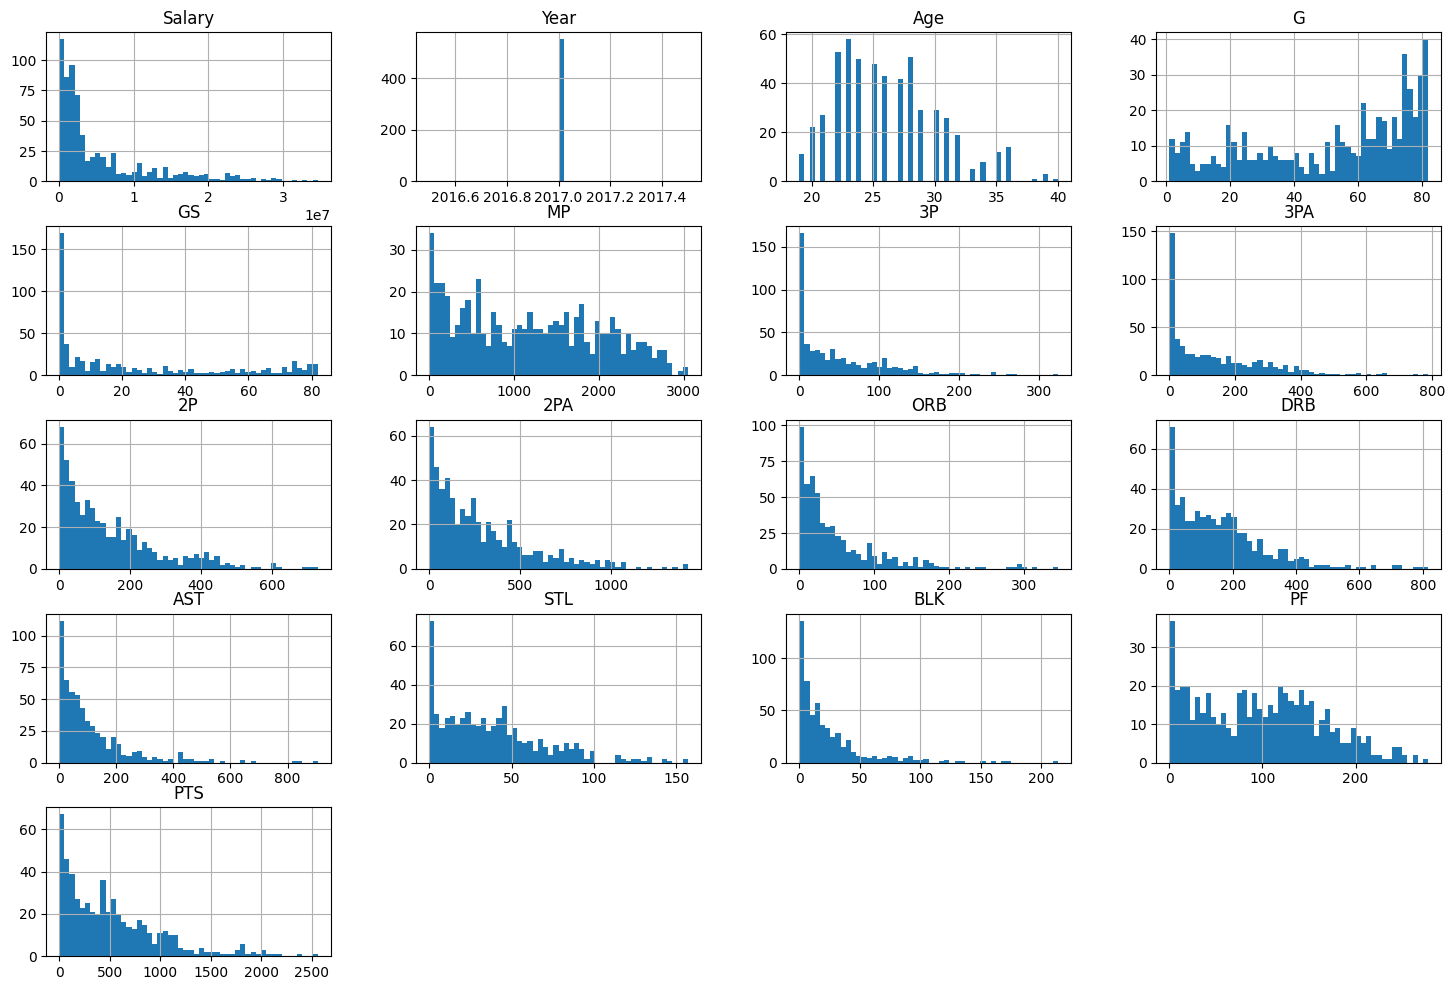

In [9]:
df.hist(bins=50,figsize=(18, 12))

Podemos ver como la feature Salary tiene 683 datos y todas las demás métricas a excepcion de Player y Team tienen 552 datos.

Tenemos 131 filas que tienen salario pero no tienen las demás métricas y es un problema que hay que analizar y solucionar. Analizando el dataframe podemos ver que hay jugadores que tienen varios registros y eso se debe a que estos jugadorss han sido transpasados a otros equipos durante la temporada, por lo que tienen varias filas con diferentes equipos y para ello debemos quedarnos con una fila por jugador para no falsear los resultados.



### 2.4 LIMPIEZA DE DATOS

In [10]:
df_clean = df.copy()
# eliminamos los jugadores para las columnas que no tienen datos en 'Year', 'Age', 'Pos', 'G', 'GS', 'MP', '3P', '3PA', '2P', '2PA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'PF', 'PTS', 'Salary'
# Esto se hace debido a que estos jugadores no tienen estadisticas completas y no aportan valor al análisis.
df_clean = df_clean.dropna(subset=['Year', 'Age', 'Pos', 'G', 'GS', 'MP', '3P', '3PA', '2P', '2PA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'PF', 'PTS', 'Salary'])
df_clean

,Player,Team,Salary,Year,Age,Pos,G,GS,MP,3P,3PA,2P,2PA,ORB,DRB,AST,STL,BLK,PF,PTS
0,Stephen Curry,GSW,34682550.0,2017.0,28.0,PG,79.0,79.0,2638.0,324.0,789.0,351.0,654.0,61.0,292.0,523.0,143.0,17.0,183.0,1999.0
1,LeBron James,CLE,33285709.0,2017.0,32.0,SF,74.0,74.0,2794.0,124.0,342.0,612.0,1002.0,97.0,543.0,646.0,92.0,44.0,134.0,1954.0
2,Paul Millsap,DEN,31269231.0,2017.0,31.0,PF,69.0,67.0,2343.0,75.0,241.0,355.0,731.0,111.0,422.0,252.0,90.0,62.0,186.0,1246.0
3,Gordon Hayward,BOS,29727900.0,2017.0,26.0,SF,73.0,73.0,2516.0,149.0,374.0,396.0,782.0,49.0,344.0,252.0,73.0,20.0,117.0,1601.0
4,Blake Griffin,DET,29512900.0,2017.0,27.0,PF,61.0,61.0,2076.0,38.0,113.0,441.0,858.0,111.0,385.0,300.0,58.0,23.0,157.0,1316.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,Quinn Cook,NOP,25000.0,2017.0,23.0,PG,5.0,0.0,77.0,5.0,14.0,6.0,11.0,0.0,3.0,12.0,1.0,0.0,6.0,27.0
678,Quinn Cook,NOP,25000.0,2017.0,23.0,PG,9.0,0.0,111.0,6.0,12.0,16.0,29.0,1.0,3.0,14.0,3.0,0.0,7.0,52.0
680,Beno Udrih,DET,25000.0,2017.0,34.0,PG,39.0,0.0,560.0,11.0,32.0,81.0,165.0,6.0,51.0,131.0,13.0,0.0,29.0,227.0
681,Joel Bolomboy,MIL,22248.0,2017.0,23.0,PF,12.0,0.0,53.0,1.0,4.0,8.0,12.0,4.0,13.0,2.0,1.0,2.0,1.0,22.0


In [11]:

jugadores_duplicados = df_clean['Player'].value_counts()[df_clean['Player'].value_counts() > 1]
jugadores_duplicados

Player
Briante Weber       9
DeAndre Liggins     9
Ersan Ilyasova      8
Quinn Cook          6
Troy Williams       6
                   ..
Jamal Crawford      2
Jameer Nelson       2
Anthony Tolliver    2
Joe Johnson         2
Joel Bolomboy       2
Name: count, Length: 66, dtype: int64

In [12]:
jugadores_duplicados_list = jugadores_duplicados.index.tolist()

print(f"Total de jugadores duplicados: {len(jugadores_duplicados_list)}, Nombres: {jugadores_duplicados_list}")

Total de jugadores duplicados: 66, Nombres: ['Briante Weber', 'DeAndre Liggins', 'Ersan Ilyasova', 'Quinn Cook', 'Troy Williams', 'Omri Casspi', 'Lance Stephenson', 'Yogi Ferrell', 'Kyle Korver', 'Sean Kilpatrick', 'Joffrey Lauvergne', 'DeMarcus Cousins', 'Deron Williams', 'Jerami Grant', "Johnny O'Bryant", 'Buddy Hield', 'Tyler Ennis', 'Jusuf Nurkic', 'Andrew Nicholson', 'Wayne Selden', 'Matt Barnes', 'Justin Anderson', 'P.J. Tucker', 'Corey Brewer', 'Miles Plumlee', 'Cameron Payne', 'Spencer Hawes', 'Andrew Bogut', 'Langston Galloway', 'Lou Williams', 'Chris McCullough', 'Jose Calderon', 'Mason Plumlee', 'Serge Ibaka', 'Taj Gibson', 'Derrick Williams', 'Axel Toupane', 'Nerlens Noel', 'K.J. McDaniels', 'Jarell Eddie', 'Chasson Randle', 'Demetrius Jackson', 'Terrence Ross', 'Doug McDermott', 'Mike Dunleavy', 'Brandon Jennings', 'Isaiah Canaan', 'Bojan Bogdanovic', 'Tyreke Evans', 'Quincy Acy', 'Dwyane Wade', 'Diamond Stone', 'Arron Afflalo', 'Georgios Papagiannis', 'Ramon Sessions', 'W

Tenemos un total de 66 jugadores duplicados por los siguientes motivos:
 - Traspasos entre equipos durante la temporada.

Procedemos a limpiar el dataset eliminando las filas duplicadas y quedándonos con una sola entrada por jugador, debido a que hay jugadores que han jugado en varios equipos durante la temporada.
 - Salario (Acumulamos el salario total del jugador en la temporada): sumamos el salario total del jugador en la temporada.
 - Rendimiento (métricas individuales): seleccionamos la fila que representa la temporada completa evitando duplicados o triplicar las estadísticas de juego de un jugador.

Esto se hace así debido a que al estar un jugador triplicado, si ordenamos por G (número de partidos jugados) y eliminamos duplicados, nos quedamos con la fila que representa la temporada completa del jugador, debido a que es un Resumen de las otras filas.


In [13]:
# Suma de contratos
df_salarios = df_clean[['Player', 'Team', 'Salary']].drop_duplicates()
salarios_reales = df_salarios.groupby('Player')['Salary'].sum().reset_index()

# Máximo de partidos
df_stats_unique = df_clean.sort_values('G', ascending=False).drop_duplicates('Player', keep='first')


df_clean = pd.merge(df_stats_unique.drop('Salary', axis=1), salarios_reales, on='Player', how='inner')


print(f"Comprobación de jugadores duplicados tras limpieza: Jugadores criticos {len(jugadores_duplicados)}")


count_elim = 0
count_ok = 0

for jugador in jugadores_duplicados.index:
    filas = df_clean[df_clean['Player'] == jugador]
    if filas.empty:
        # Si no está en df_clean, es que se eliminó (tenía NaNs)
        print(f"{jugador}: ELIMINADO (Datos insuficientes/NaN)")
        count_elim += 1
    else:
        # Si está, verificamos que sea único y tenga salario sumado
        salario = filas['Salary'].values[0]
        partidos = filas['G'].values[0]
        print(f"{jugador}: UNIFICADO (Salario Total: ${salario:,.0f} | Partidos: {partidos})")
        count_ok += 1

print("-" * 60)
print(f"RESUMEN FINAL: {count_ok} Unificados correctamente | {count_elim} Eliminados por basura (NaNs)")
print(f"Dimensiones finales del dataset: {df_clean.shape}")

Comprobación de jugadores duplicados tras limpieza: Jugadores criticos 66
Briante Weber: UNIFICADO (Salario Total: $183,129 | Partidos: 20.0)
DeAndre Liggins: UNIFICADO (Salario Total: $1,776,241 | Partidos: 62.0)
Ersan Ilyasova: UNIFICADO (Salario Total: $6,502,328 | Partidos: 82.0)
Quinn Cook: UNIFICADO (Salario Total: $125,000 | Partidos: 14.0)
Troy Williams: UNIFICADO (Salario Total: $1,619,700 | Partidos: 30.0)
Omri Casspi: UNIFICADO (Salario Total: $2,106,470 | Partidos: 36.0)
Lance Stephenson: UNIFICADO (Salario Total: $4,180,000 | Partidos: 18.0)
Yogi Ferrell: UNIFICADO (Salario Total: $1,312,611 | Partidos: 46.0)
Kyle Korver: UNIFICADO (Salario Total: $7,000,000 | Partidos: 67.0)
Sean Kilpatrick: UNIFICADO (Salario Total: $2,486,268 | Partidos: 70.0)
Joffrey Lauvergne: UNIFICADO (Salario Total: $1,524,305 | Partidos: 70.0)
DeMarcus Cousins: UNIFICADO (Salario Total: $18,063,850 | Partidos: 72.0)
Deron Williams: UNIFICADO (Salario Total: $5,500,000 | Partidos: 64.0)
Jerami Gran

### Volvemos a comprobar el dataset tras la limpieza

In [14]:
df_clean.head()

,Player,Team,Year,Age,Pos,G,GS,MP,3P,3PA,2P,2PA,ORB,DRB,AST,STL,BLK,PF,PTS,Salary
0,Joe Ingles,UTA,2017.0,29.0,SF,82.0,26.0,1972.0,123.0,279.0,81.0,172.0,23.0,237.0,224.0,96.0,8.0,163.0,581.0,14136364.0
1,Tobias Harris,LAC,2017.0,24.0,PF,82.0,48.0,2567.0,109.0,314.0,402.0,749.0,63.0,353.0,142.0,60.0,39.0,133.0,1321.0,16000000.0
2,Ersan Ilyasova,ATL,2017.0,29.0,PF,82.0,52.0,2142.0,142.0,402.0,242.0,488.0,115.0,366.0,141.0,58.0,23.0,211.0,1071.0,6502328.0
3,Gorgui Dieng,MIN,2017.0,27.0,PF,82.0,82.0,2653.0,16.0,43.0,316.0,618.0,188.0,459.0,158.0,88.0,95.0,254.0,816.0,14112360.0
4,Andrew Wiggins,MIN,2017.0,21.0,SF,82.0,82.0,3048.0,103.0,289.0,606.0,1281.0,103.0,226.0,189.0,82.0,30.0,183.0,1933.0,7574322.0


In [15]:
df_clean.isnull().sum()

Player    0
Team      0
Year      0
Age       0
Pos       0
G         0
GS        0
MP        0
3P        0
3PA       0
2P        0
2PA       0
ORB       0
DRB       0
AST       0
STL       0
BLK       0
PF        0
PTS       0
Salary    0
dtype: int64

In [16]:
df_clean.describe()

,Year,Age,G,GS,MP,3P,3PA,2P,2PA,ORB,DRB,AST,STL,BLK,PF,PTS,Salary
count,411.0,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,4.110000e+02
mean,2017.0,26.141119,58.829684,29.197080,1381.944039,56.046229,156.012165,169.450122,336.306569,57.722628,191.953771,129.661800,44.209246,27.311436,113.564477,610.309002,7.642253e+06
std,0.0,4.267236,21.789463,29.227411,800.840351,57.726988,151.116132,144.087877,278.307548,59.318618,148.318659,138.266692,32.360470,30.365021,63.033964,489.637107,7.664253e+06
min,2017.0,19.000000,2.000000,0.000000,9.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.500000e+04
25%,2017.0,23.000000,46.000000,2.000000,713.500000,5.000000,20.000000,57.500000,122.000000,18.000000,84.500000,40.000000,19.000000,7.000000,65.000000,228.500000,1.653850e+06
50%,2017.0,26.000000,66.000000,18.000000,1391.000000,42.000000,118.000000,129.000000,265.000000,39.000000,168.000000,88.000000,40.000000,19.000000,118.000000,515.000000,4.402546e+06
75%,2017.0,29.000000,76.000000,59.000000,2056.000000,90.500000,254.000000,237.000000,469.500000,79.500000,255.500000,171.000000,61.500000,36.000000,154.500000,845.500000,1.200000e+07
max,2017.0,40.000000,82.000000,82.000000,3048.000000,324.000000,789.000000,730.000000,1421.000000,345.000000,817.000000,906.000000,157.000000,214.000000,278.000000,2558.000000,3.468255e+07


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Age'}>, <Axes: title={'center': 'G'}>,
        <Axes: title={'center': 'GS'}>],
       [<Axes: title={'center': 'MP'}>, <Axes: title={'center': '3P'}>,
        <Axes: title={'center': '3PA'}>, <Axes: title={'center': '2P'}>],
       [<Axes: title={'center': '2PA'}>, <Axes: title={'center': 'ORB'}>,
        <Axes: title={'center': 'DRB'}>, <Axes: title={'center': 'AST'}>],
       [<Axes: title={'center': 'STL'}>, <Axes: title={'center': 'BLK'}>,
        <Axes: title={'center': 'PF'}>, <Axes: title={'center': 'PTS'}>],
       [<Axes: title={'center': 'Salary'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

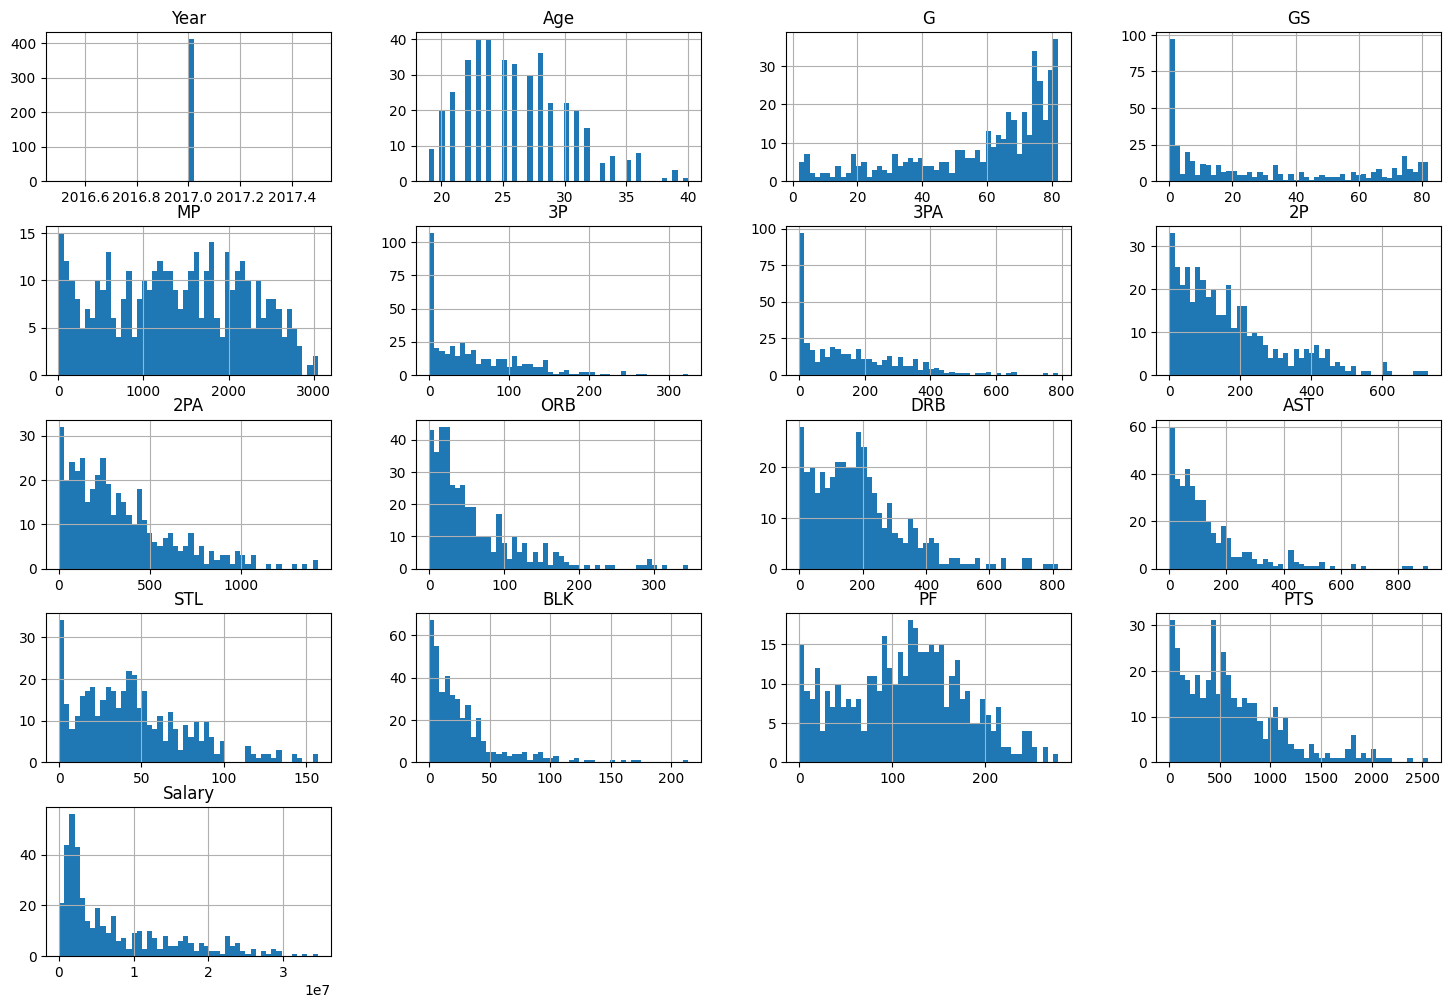

In [17]:
df_clean.hist(bins=50,figsize=(18, 12))

## Análisis de correlación
Creamos variables categóricas para las columnas 'Pos' y 'Team' mediante One-Hot Encoding.
Cada categoria se convierte en una columna binaria (0 o 1) indicando la presencia de esa categoría en la fila correspondiente. (1 pertenece a esa categoría, 0 no pertenece).

Al introducir One-Hot Encoding, podemos entender mejor cómo correlacionan las posiciones con el salario, ó cómo correlacionan los equipos con el salario. De forma que nos permite analizar el impacto de estas variables categóricas en la predicción del salario.

Los colores rojos nos indican que esta característica aumenta el salario y el azul que lo disminuye.

In [ ]:
df_dummy = pd.get_dummies(df_clean, columns=['Pos', 'Team'], drop_first=False)

corr_matrix = df_dummy.corr(numeric_only=True)

# Nos quedamos con las variables que más correlacionan con 'Salary'
columns_of_interest = corr_matrix['Salary'].abs().sort_values(ascending=False).head(20).index
corr_matrix = corr_matrix.loc[columns_of_interest, columns_of_interest]

fig = px.imshow(corr_matrix,
                title='Matriz de Correlación de Variables Numéricas',
                labels=dict(x="Variables", y="Variables", color="Correlación"),
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1,
                text_auto=".2f",
                aspect="auto",origin='lower')

fig.update_layout(width=1400, height=800)
fig.show()


## Analisis del rendimiento: Salary vs métricas claves

Analizamos cómo las estadisticas Puntos, Asistencias y Rebotes afectan al salario de los jugadores.

El objetivo es buscar **líneas de tendencia** que nos indiquen cómo estas métricas influyen en el salario. (más puntos = más salario, etc)

Los puntos muy alejados **dispersos** de la linea de tendencia indican "Anomalías" o "outliers", es decir, jugadores que ganan mucho más o mucho menos de lo que su rendimiento indicaría. (Jugadores a los que se les paga mucho más por su fama, marketing, etc)



In [19]:
top_metrics = ['PTS','2P','2PA','GS','MP','DRB','STL','AST','PF','3P','3PA','ORB','BLK','G','Age']
top_metrics = [c for c in top_metrics if c in df.columns]

for col in top_metrics:
    fig = px.scatter(
        df_clean, x=col, y="Salary",
        color='Pos' if 'Pos' in df_clean.columns else None,
        hover_data=[c for c in ["Player", "Team", "Pos", "Age", "MP", col, "Salary"] if c in df.columns],
        trendline="ols"
    )
    fig.update_layout(title=f"Salary vs {col}", width=800, height=600)

    fig.show()

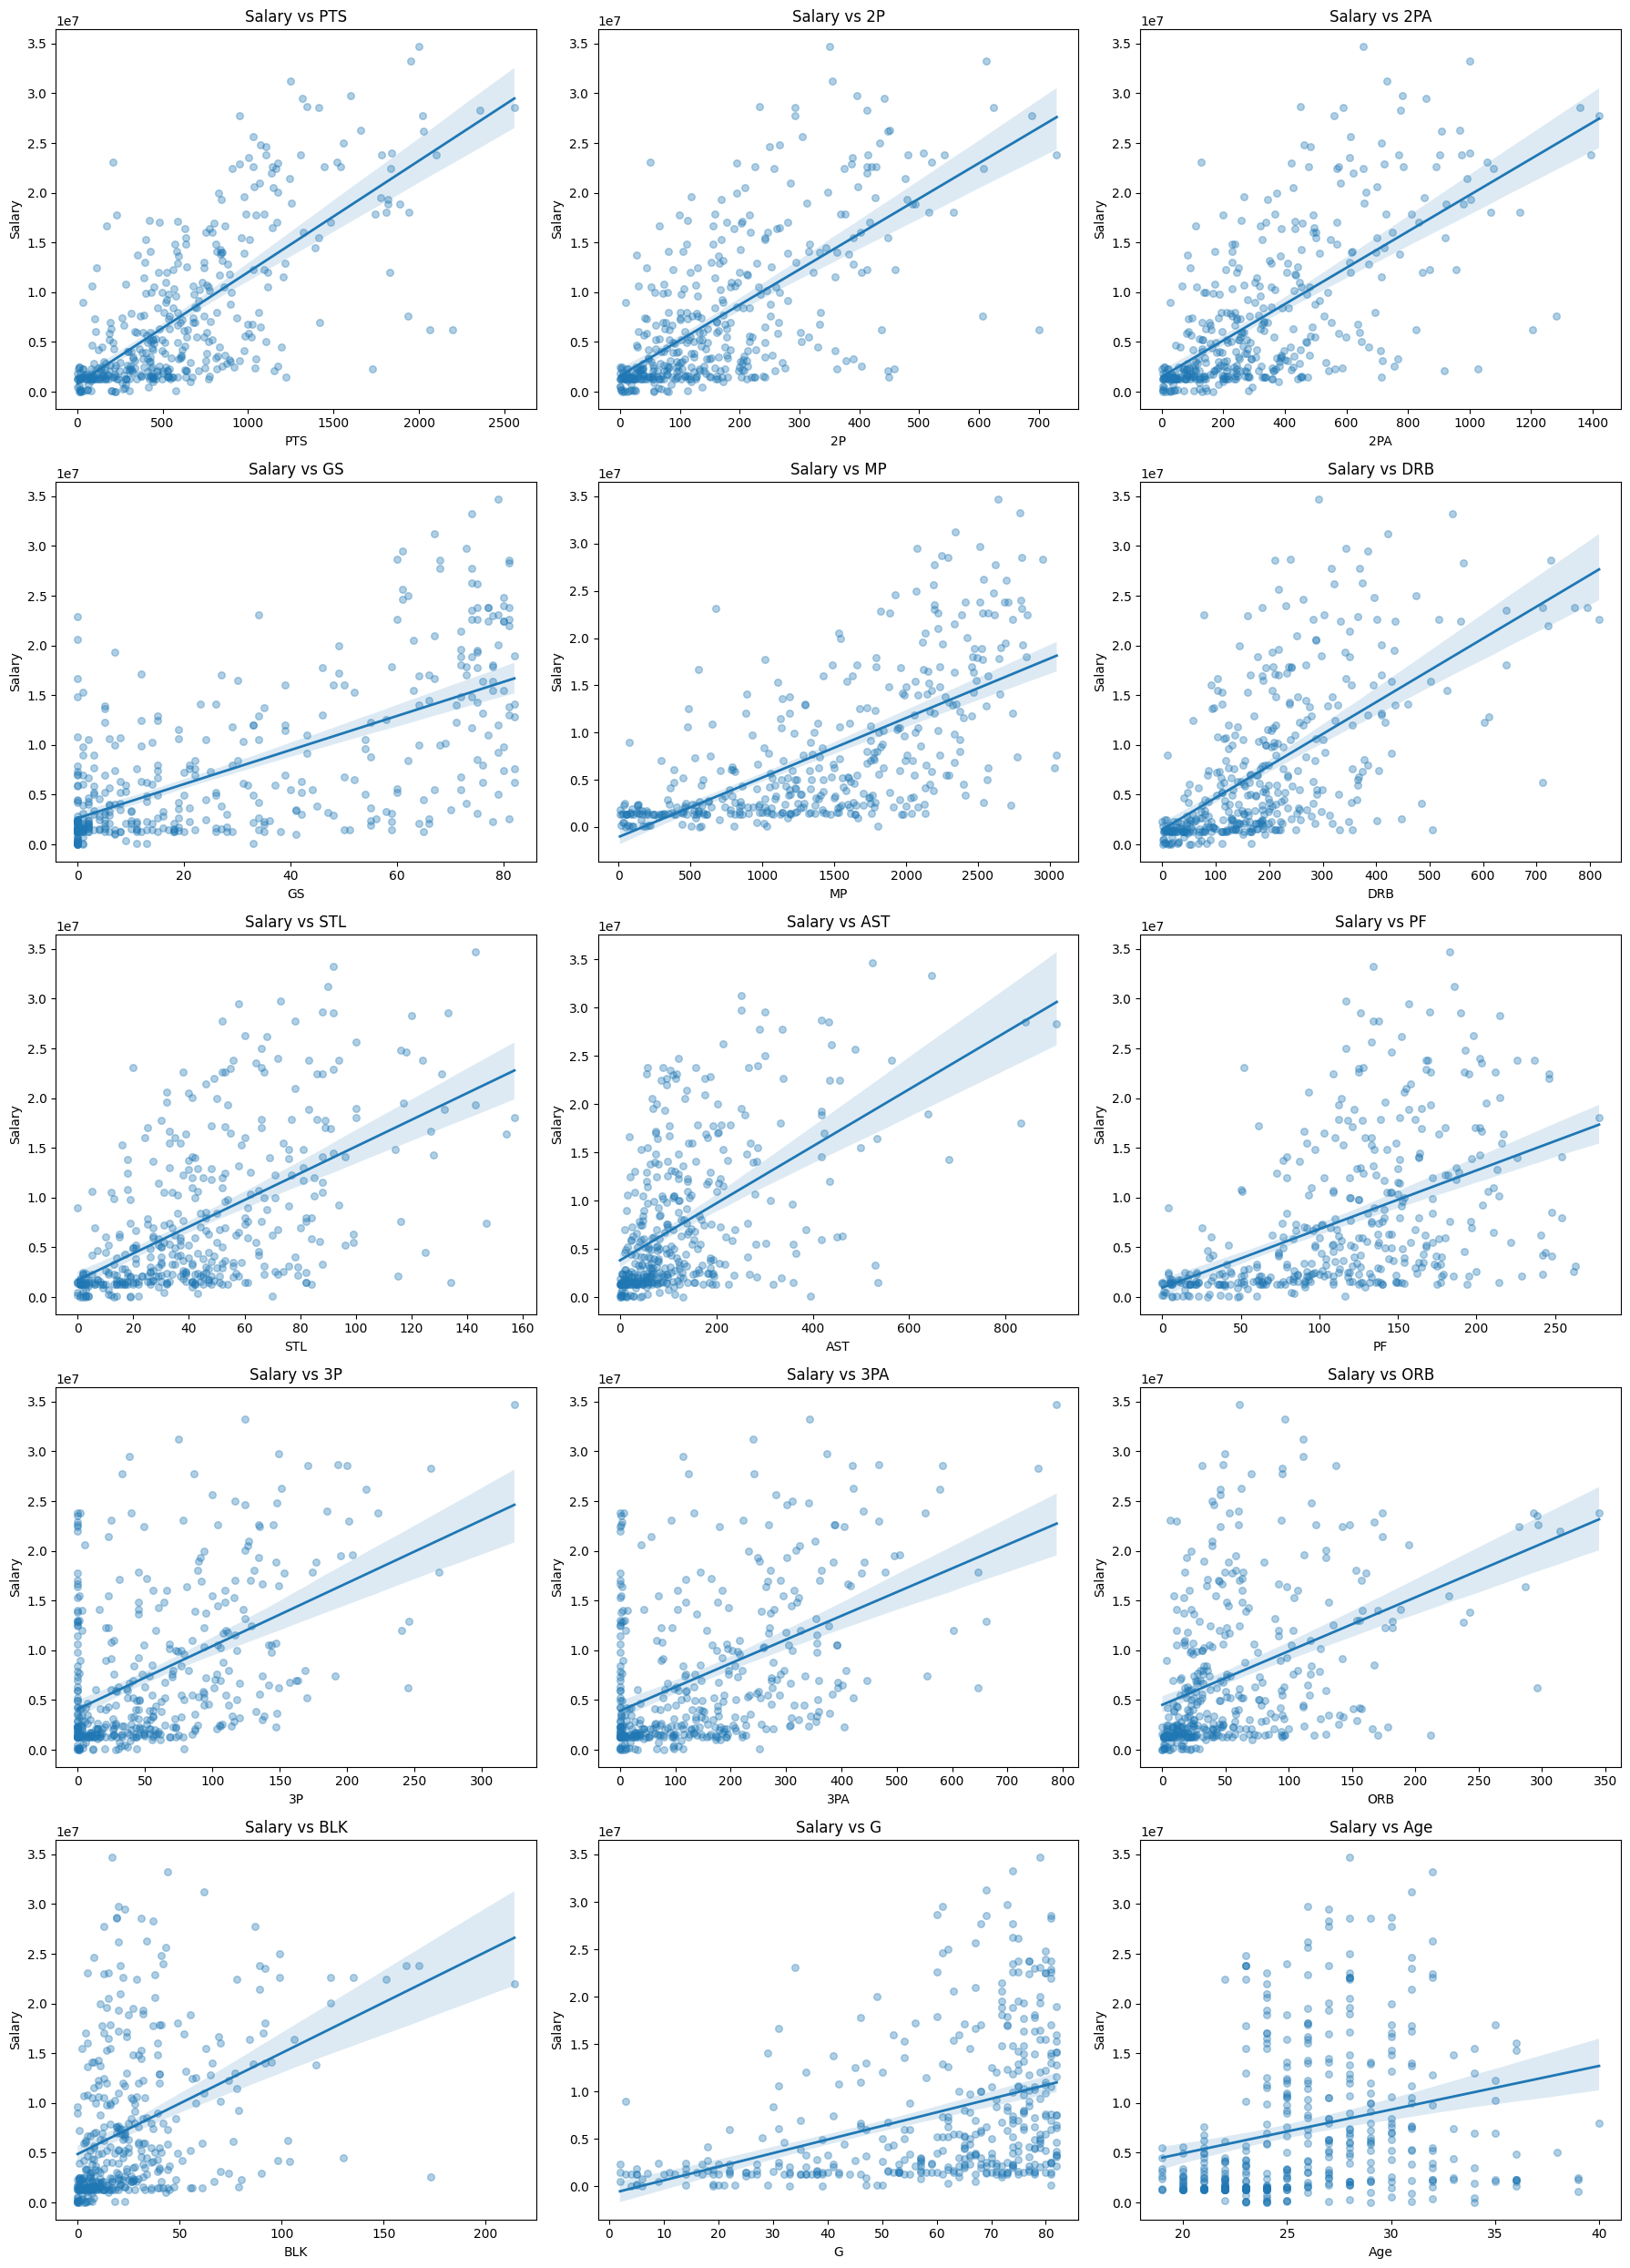

In [20]:
n = len(top_metrics)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(18, 5*nrows))
for i, col in enumerate(top_metrics, 1):
    ax = plt.subplot(nrows, ncols, i)
    sns.regplot(
        data=df_clean, x=col, y='Salary',
        scatter_kws={'alpha':0.35, 's':30}, line_kws={'lw':2}
    )
    ax.set_title(f'Salary vs {col}')
plt.tight_layout()
plt.show()


## Distribución del salario según la posición del jugador y el equipo al que pertenece

Queremos ver la distribución del salario en función de la posición del jugador (Pos) y el equipo (Team) al que pertenece un jugador.

Los equipos con cajas más altas indican que tienen jugadores con salarios más altos en promedio, en cambio, los equipos con cajas más bajas indican que tienen jugadores con salarios más bajos en promedio ( o plantillas mas equilibradas).

In [21]:
fig_pos = px.box(
    df_clean, x='Pos', y='Salary', color='Pos',
    points="all",
    hover_data=["Player"],
    title="Distribución del Salario según la Posición del Jugador")

fig_pos.update_layout(width=800, height=600, xaxis_title="Posición del Jugador", yaxis_title="Salario (USD)")
fig_pos.show()

In [22]:
total_teams = df_clean['Team'].nunique()
print(f"Número total de equipos: {total_teams}")

Número total de equipos: 30


In [23]:
top_teams = df_clean.groupby('Team')['Salary'].median().sort_values(ascending=False).head(15).index
df_top_teams = df_clean[df_clean['Team'].isin(top_teams)]

fig_team = px.violin(df_top_teams, x='Team', y='Salary', color='Team',
                     box=True, # Dibuja el boxplot dentro del violín
                     points="all",
                     hover_data=['Player'],
                     category_orders={'Team': list(top_teams)}, # Ordenar por mediana
                     title='Distribución Salarial en los 15 Equipos con Mediana más Alta')
fig_team.show()

In [24]:
top_teams = df_clean.groupby('Team')['Salary'].median().sort_values(ascending=False).index
df_top_teams = df_clean[df_clean['Team'].isin(top_teams)]

fig_team = px.violin(df_top_teams, x='Team', y='Salary', color='Team',
                     box=True, # Dibuja el boxplot dentro del violín
                     points="all",
                     hover_data=['Player'],
                     category_orders={'Team': list(top_teams)}, # Ordenar por mediana
                     title='Distribución Salarial de todos los Equipos con Mediana más Alta')
fig_team.update_layout(width=2000, height=600)
fig_team.show()

## Analisis Multivariante

Podemos visualizar interacciones complejas entre las variables más deterministas como pueden ser los Puntos (PTS), Minutos Jugados (MP), Asistencias (AST), Age (Edad)
para entender mejor cómo estas métricas combinadas afectan al salario de los jugadores.

1) Es muy importante jugar muchos minutos para cobrar más, pero el mercado o los equipos premiam más a los jugadores que más anotan.
   1) Relación positiva entre PTS y MP: los jugadores que juegan más minutos tienden a anotar más puntos.
   2) Relación positiva entre PTS y Salary: los jugadores que anotan más puntos tienden a tener salarios más altos.

2) Relación AST y Salary:
   1) Los jugadores que más asistencias reparten (AST) también tienden a tener salarios más altos, destancan los jugadores cuya posición es Base (PG).
3) Relación DRB y Salary:
   1) Los jugadores que capturan más rebotes defensivos (DRB) también tienden a tener salarios más altos. Los jugadores cuya posición es Pívot (C) o Ala-Pívot (PF) destacan en esta métrica.
4) Edad (Age) y Salary:
   1) Los contratos más altos se concentran en la franja de edad de 25-26 a 30-31 años, que suele ser la etapa de mayor rendimiento para los jugadores de la NBA.
   2) Los veteranos > 32 años, tiene mucha dispersion en sus salarios, ya que algunos jugadores veteranos siguen cobrando altos salarios debido a su experiencia y reputación, mientras que otros pueden tener contratos más bajos debido a la disminución del rendimiento o a roles más limitados en el equipo.

In [ ]:
cols_pairplot = ['Salary', 'PTS','MP', 'Age', 'AST', 'DRB'] # '2P','2PA', '3P','3PA'

fig_matrix = px.scatter_matrix(
    df_clean,
    dimensions=cols_pairplot,
    color='Pos',
    symbol='Pos',
    title='Matriz de Dispersión Multivariante (Scatter Matrix)',
    opacity=0.7,
    hover_data=['Player']
)

fig_matrix.update_traces(diagonal_visible=False)
fig_matrix.update_layout(height=800, width=800)
fig_matrix.show()

## 3. Desarrollo modelo predictivo

1. Transformación logaritmica de la variable objetivo (Salary) para reducir la influencia de valores atípicos y mejorar la estabilidad del modelo.
   1. En datos financieros (sueldos) no sigue una distribución normal (Campana de Gauss), sino que suele estar sesgada (algunos jugadores ganan muchísimo más que la media). La mayoria de jugadores tienen salarios bajos (2-5M) o medios, y unos pocos tienen salarios extremadamente altos (30M). Al aplicar la transformación logarítmica, reducimos el impacto de estos valores atípicos y hacemos que la distribución de los salarios sea más simétrica y cercana a una distribución normal.
   2. Si entrenamos el modelo con datos reales, el algoritmo del modelo intenta minimizar el error error absolutor en los contratos más altos, lo que puede llevar a un sobreajuste en estos casos y a un rendimiento deficiente en la predicción de salarios más bajos. Al aplicar la transformación logarítmica, el modelo se enfoca en minimizar los errores relativos en lugar de los errores absolutos, lo que mejora la capacidad del modelo para predecir salarios en todo el rango. Además las Redes Neuronales suelen funcionar mejor cuando la variable objetivo tiene una distribución más cercana a la normal.
   3. Para solucionar esto aplicamos np.log1p() a la variable objetivo Salary antes de entrenar el modelo, conviertiendo la variable objetivo en una distribución logarítmica más parecida a una distribución normal.
   4. Las features no usamos la transformación logarítmica, si no que las estandarizamos con StandardScaler(), es la forma más efectiva de centrar los datos en torno a 0 con desviación estándar 1, lo que mejora la convergencia del modelo y su rendimiento.
2. Métricas de evaluación: RMSE y R²
   1.  RMSE (Root Mean Squared Error): Mide la desviación estándar de los errores de predicción. Penaliza fuertemente los errores grandes (outliers). Lo calcularemos sobre la escala logarítmica para ver el error del modelo, y luego lo traduciremos a dólares para comunicarlo al cliente.
   2. $R^2$ (Coeficiente de Determinación): Nos indica qué porcentaje de la variabilidad del salario es capaz de "explicar" nuestro modelo. Un 1.0 sería un modelo perfecto; un 0.0 es un modelo que solo predice el promedio.

In [26]:
def split_feature_labels(df: pd.DataFrame, target_column:str )-> tuple[pd.DataFrame, pd.Series]:
    """
    split_feature_labels separa las características (features) de la variable objetivo (target) en un DataFrame.

    :param df: df DataFrame con los datos completos
    :type df: pd.DataFrame
    :param target_column:  Nombre de la columna objetivo
    :type target_column: str
    :return: X, y donde X son las características e y es la variable objetivo
    :rtype: pd.DataFrame, pd.Series
    """
    X = df.drop(columns=[target_column, 'Player', 'Team'])  # Nos vamos a quedar con todas las columnas excepto la objetivo y las no numéricas, el nombre y el equipo no aportan valor predictivo
    y = np.log1p(df[target_column])  # Aplicamos logaritmo natural + 1 para comprimir la escala del salario
    return X, y

def add_model(df: pd.DataFrame, model_name: str, rmse_train, r2_train, rmse_test, r2_test) -> pd.DataFrame:
    new_row = pd.DataFrame({
        'Model': [model_name],
        'RMSE Train (CV)': [rmse_train],
        'R2 Train (CV)': [r2_train],
        'RMSE Test': [rmse_test],
        'R2 Test': [r2_test]
    })
    df = pd.concat([df, new_row], ignore_index=True)
    return df.sort_values(by='RMSE Test')

In [27]:
model_comparative = pd.DataFrame(columns=['Model', 'RMSE Train (CV)', 'R2 Train (CV)', 'RMSE Test', 'R2 Test'])

In [28]:
X, y = split_feature_labels(df_clean, target_column='Salary')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos de entrenamiento: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Dimensiones de los datos de prueba: X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensiones de los datos de entrenamiento: X_train: (328, 17), y_train: (328,)
Dimensiones de los datos de prueba: X_test: (83, 17), y_test: (83,)


In [29]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = ['Pos'] # Solo la posición

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: Index(['Year', 'Age', 'G', 'GS', 'MP', '3P', '3PA', '2P', '2PA', 'ORB', 'DRB',
       'AST', 'STL', 'BLK', 'PF', 'PTS'],
      dtype='object')
Categorical features: ['Pos']


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Ya hemos definido las varias métricas de evaluación que utilizaremos para comparar los modelos predictivos:
    - RMSE (Root Mean Squared Error)
    - R2 (Coeficiente de Determinación)
    - Transformación Logarítmica del Target (Log-Salary)
    - Estandarización de las features (StandardScaler)
    - categorías One-Hot Encoding para variables categóricas (Pos)

Con el objetio de garantizar un entrenamiento robusto y evitar la fuga de datos, hemos estructurado el proceso en varias etapas:
    - División de los datos: Separamos las variable predictoras (X) y la variable objetivo (y). Luego dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%).
    - Transformación de la variable objetivo: Aplicamos la transformación logarítmica a la variable objetivo (Salary) utilizando np.log1p() para reducir la influencia de valores atípicos y mejorar la estabilidad del modelo.

Vamos a ver la distribución del target (Salary) antes y después de aplicar la transformación logarítmica.

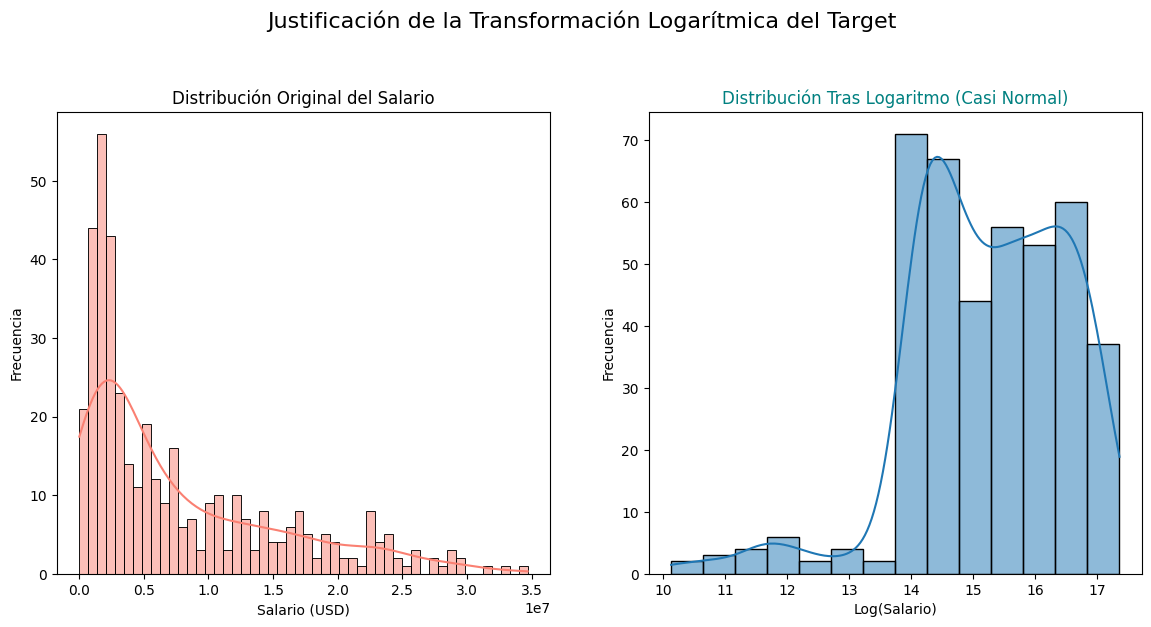

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
# Distribución original del salario
sns.histplot(df_clean['Salary'], bins=50, kde=True, ax=ax[0],color='salmon')
ax[0].set_title('Distribución Original del Salario')
ax[0].set_xlabel('Salario (USD)')
ax[0].set_ylabel('Frecuencia')


# Distribución del salario tras transformación logarítmica
sns.histplot(y, kde=True, ax=ax[1])
ax[1].set_title('Distribución Tras Logaritmo (Casi Normal)', color='teal')
ax[1].set_xlabel('Log(Salario)')
ax[1].set_ylabel('Frecuencia')

plt.suptitle('Justificación de la Transformación Logarítmica del Target', fontsize=16, y=1.05)
plt.show()

En la gráfica de la izquierda, podemos observar que la distribución del salario (Salary) es altamente asimétrica, con una larga cola hacia la derecha. Esto indica que hay unos pocos jugadores que ganan salarios extremadamente altos, mientras que la mayoría tiene salarios más bajos. Esta distribución no es ideal para el modelado predictivo, ya que puede sesgar los resultados y dificultar la convergencia de los modelos.

En la gráfica de la derecha, tras aplicar la transformación logarítmica (Log-Salary), la distribución se asemeja mucho más a una distribución normal (campana de Gauss). Esto es beneficioso para el modelado predictivo, ya que facilita que los algoritmos aprendan patrones en los datos sin ser influenciados desproporcionadamente por los valores extremos. Tras esto evitamos los sesgos de los datos originales y mejoramos la capacidad de los modelos para predecir salarios de manera más precisa y equitativa (tanto bajos como altos).

In [32]:
def visualize_predictions(y_real, y_pred, model_title):
    plt.figure(figsize=(12, 4))
    
    # Reseteamos index para que el plot lineal tenga sentido (muestra 0 a N)
    y_real_reset = y_real.reset_index(drop=True)
    
    plt.plot(y_real_reset, label='Real', color='black', alpha=0.6, linewidth=1.5)
    plt.plot(y_pred, label='Predicción', color='#FF6B6B', alpha=0.8, linewidth=1.5, linestyle='--')
    
    plt.title(f'Predicciones vs Realidad: {model_title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Modelo: LinearRegression entrenado y evaluado en 0.05 segundos.


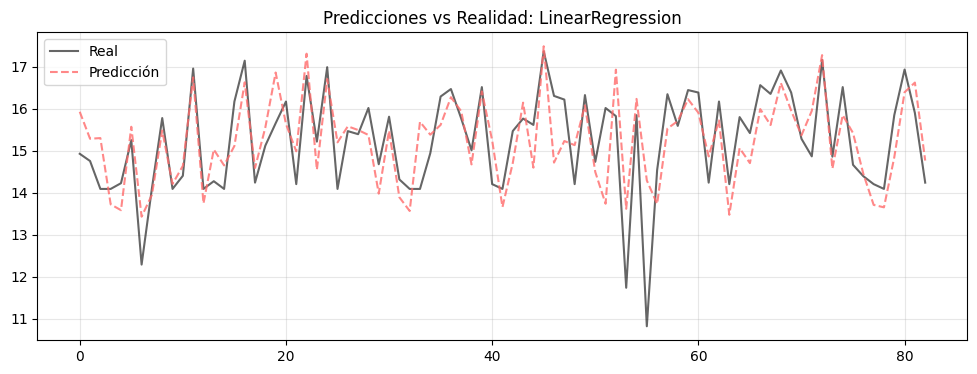

Modelo: Lasso Regression (alpha=0.001) entrenado y evaluado en 0.07 segundos.


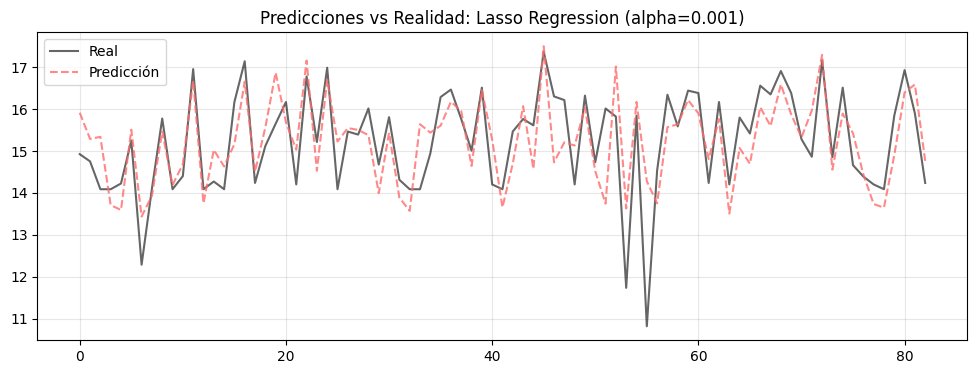

Modelo: Lasso Regression (alpha=0.01) entrenado y evaluado en 0.05 segundos.


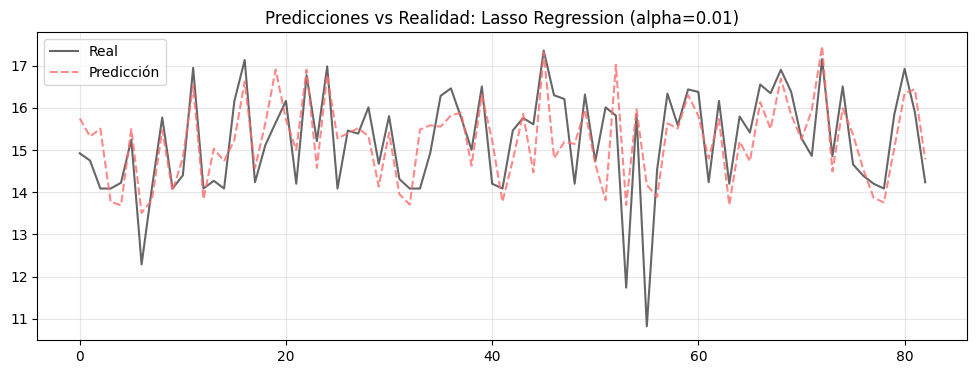

Modelo: Lasso Regression (alpha=0.1) entrenado y evaluado en 0.05 segundos.


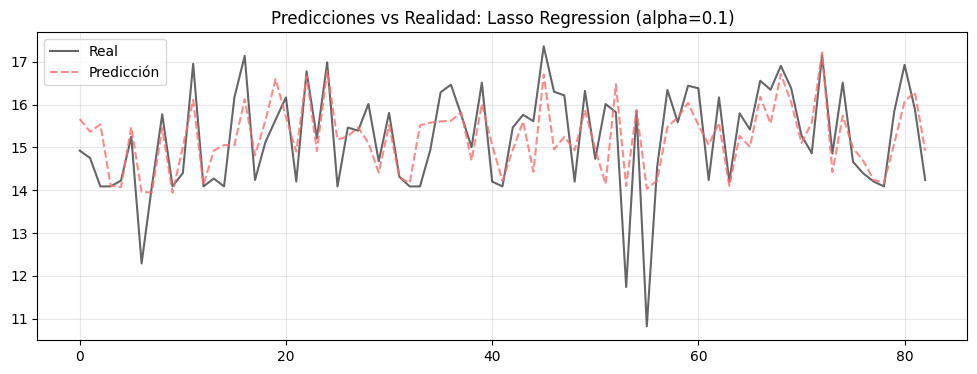

Modelo: Decision Tree entrenado y evaluado en 0.07 segundos.


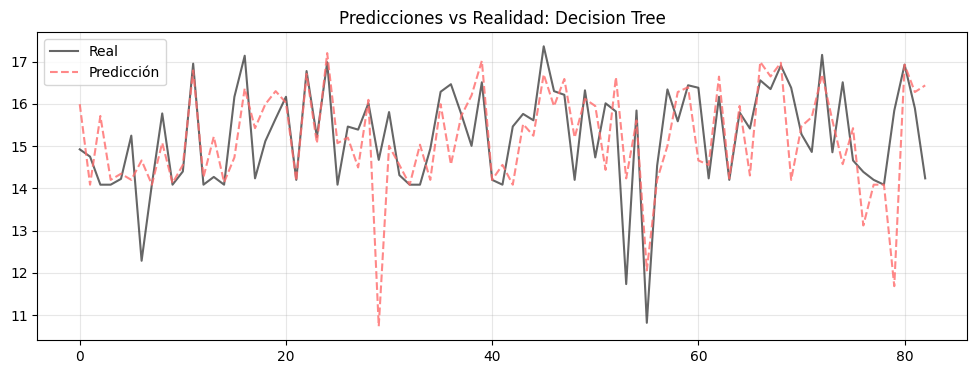

Modelo: Decision Tree (max_depth=5) entrenado y evaluado en 0.06 segundos.


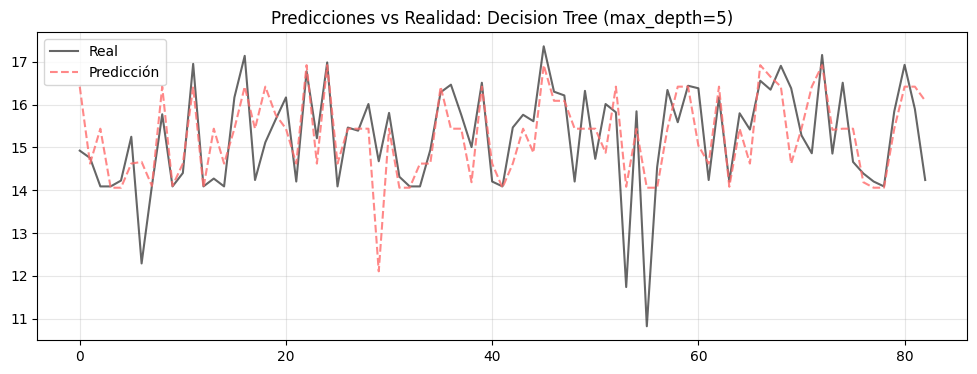

Modelo: Decision Tree (max_depth=10) entrenado y evaluado en 0.07 segundos.


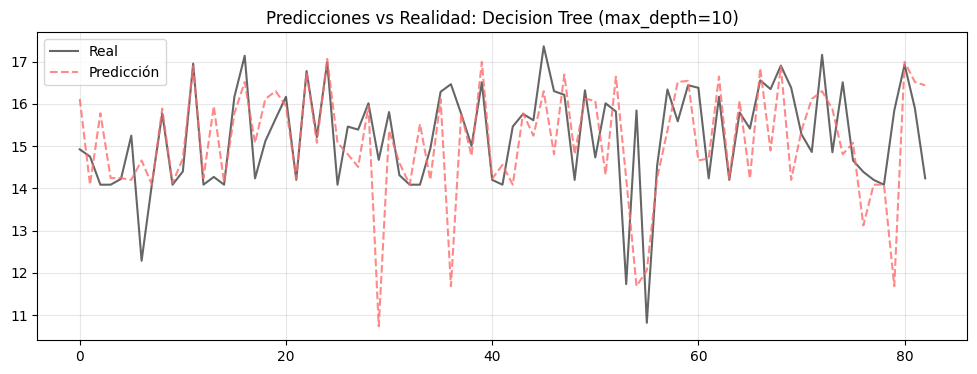

Modelo: Random Forest (n_estimators = 10) entrenado y evaluado en 0.25 segundos.


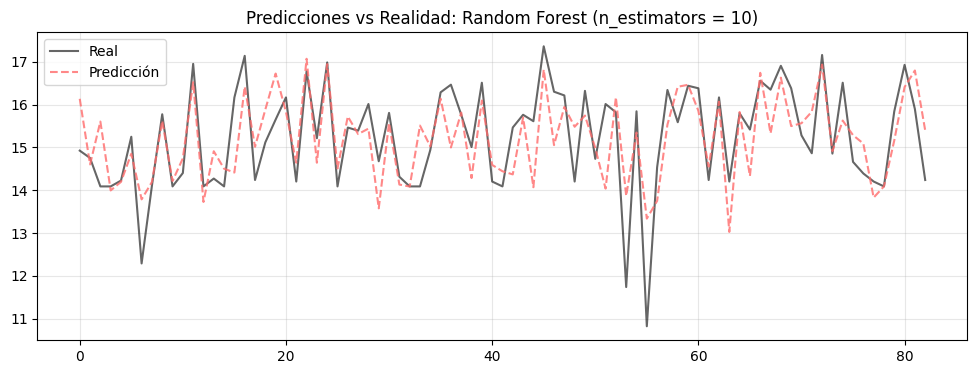

Modelo: Random Forest (n_estimators = 100) entrenado y evaluado en 2.09 segundos.


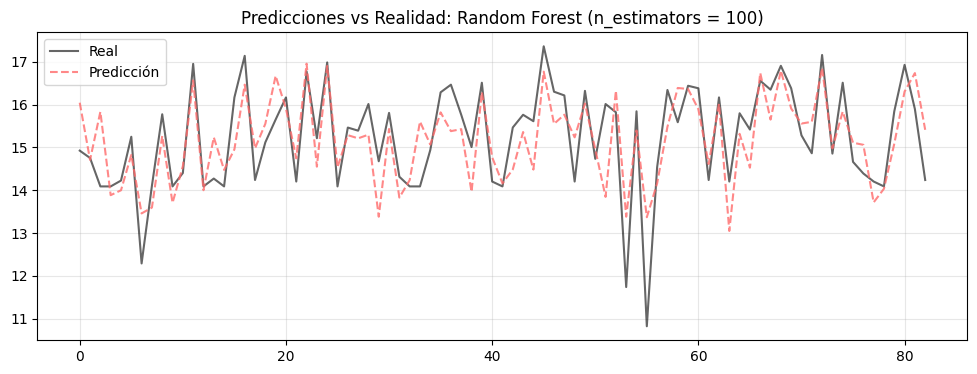

Modelo: Random Forest (n_estimators = 200) entrenado y evaluado en 3.80 segundos.


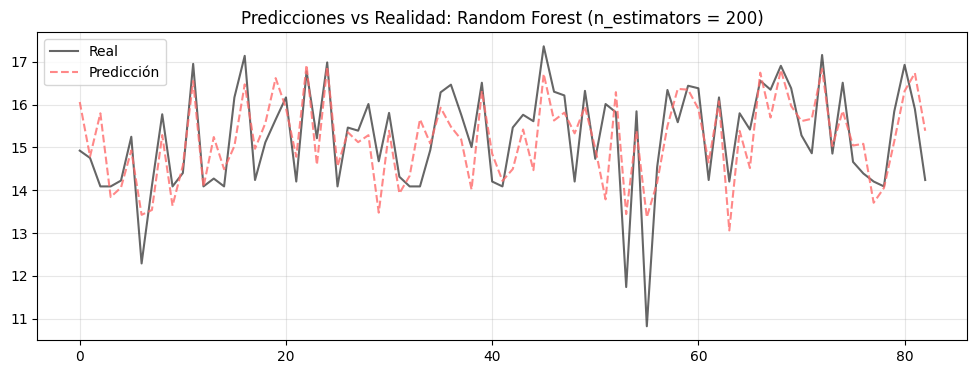

Modelo: Random Forest (n_estimators = 10, max_depth=5) entrenado y evaluado en 0.18 segundos.


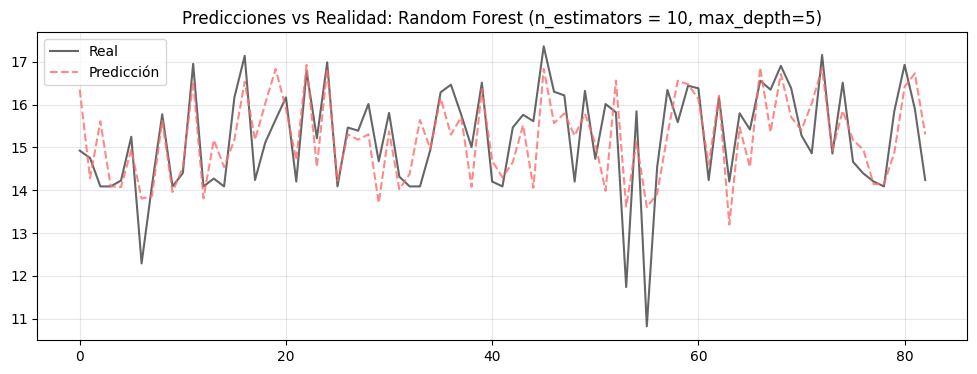

Modelo: Random Forest (n_estimators = 100, max_depth=5) entrenado y evaluado en 1.41 segundos.


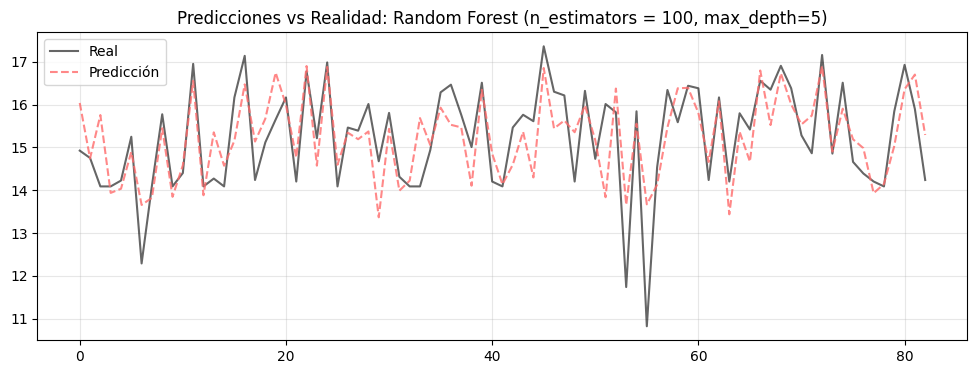

Modelo: Random Forest (n_estimators = 200, max_depth=5) entrenado y evaluado en 2.52 segundos.


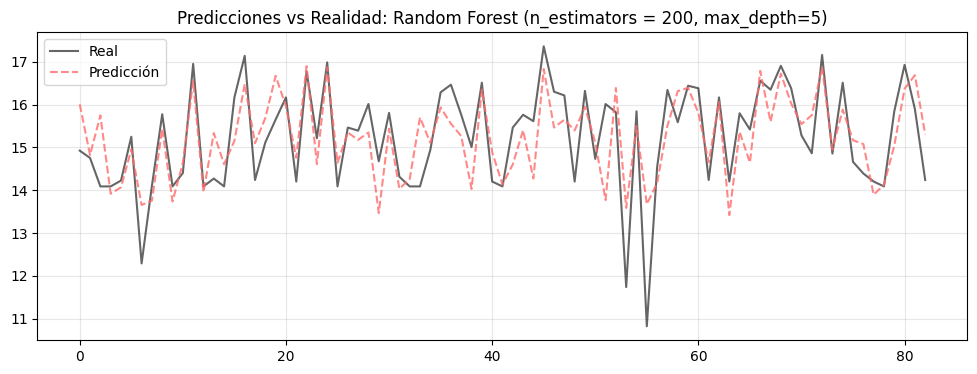

Modelo: Random Forest (n_estimators = 10, max_depth=10) entrenado y evaluado en 0.23 segundos.


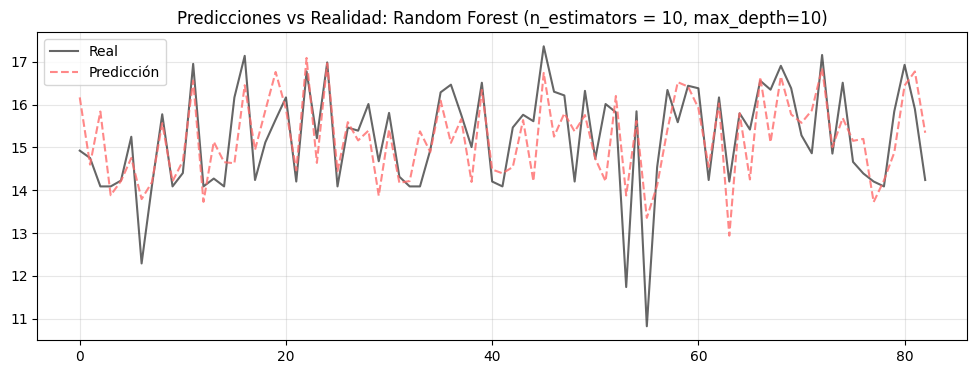

Modelo: Random Forest (n_estimators = 100, max_depth=10) entrenado y evaluado en 2.09 segundos.


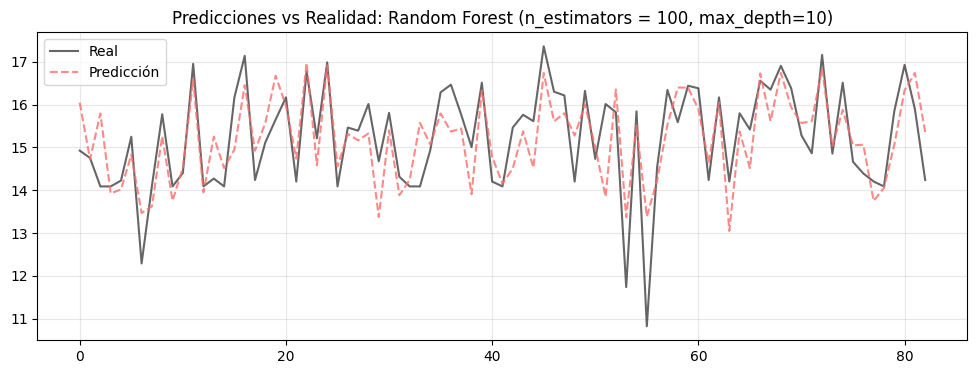

Modelo: Random Forest (n_estimators = 200, max_depth=10) entrenado y evaluado en 3.74 segundos.


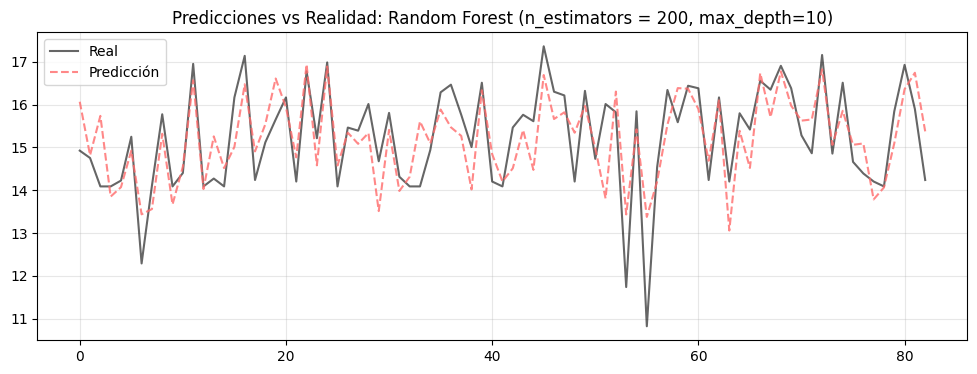

Modelo: Extra Trees entrenado y evaluado en 1.12 segundos.


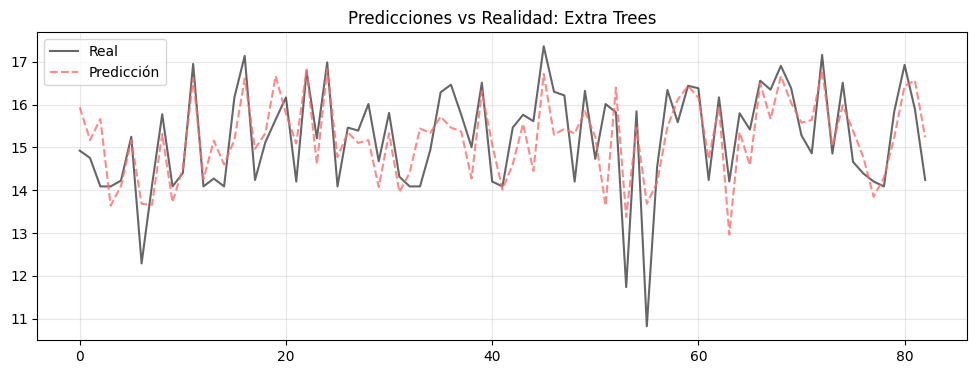

Modelo: Extra Trees (n_estimators = 10) entrenado y evaluado en 0.16 segundos.


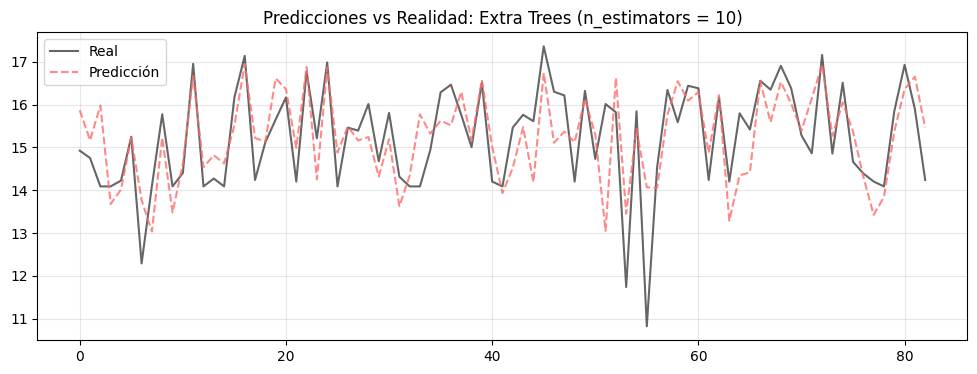

Modelo: Extra Trees (n_estimators = 100) entrenado y evaluado en 1.13 segundos.


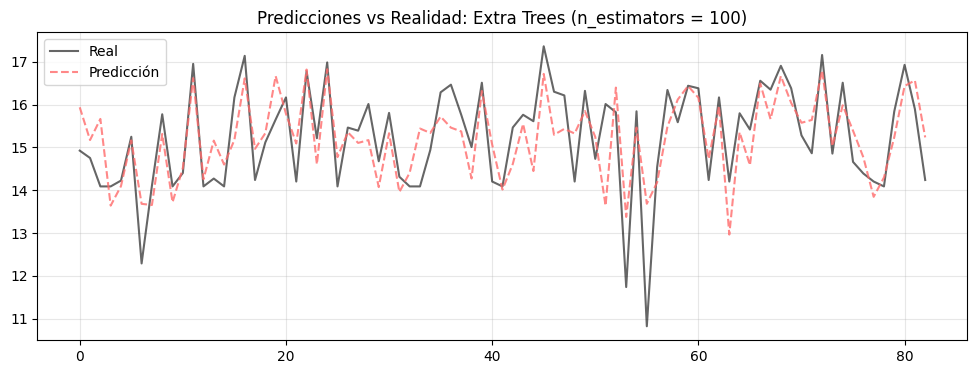

Modelo: Extra Trees (n_estimators = 200) entrenado y evaluado en 2.40 segundos.


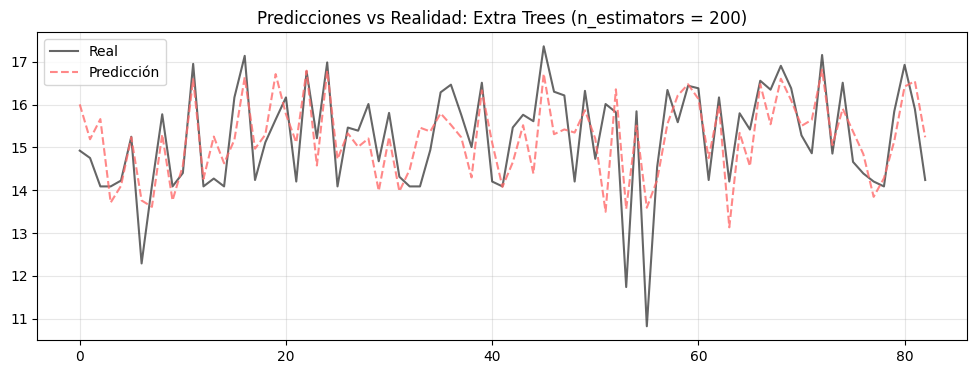

Modelo: Extra Trees (n_estimators = 10, max_depth=5) entrenado y evaluado en 0.10 segundos.


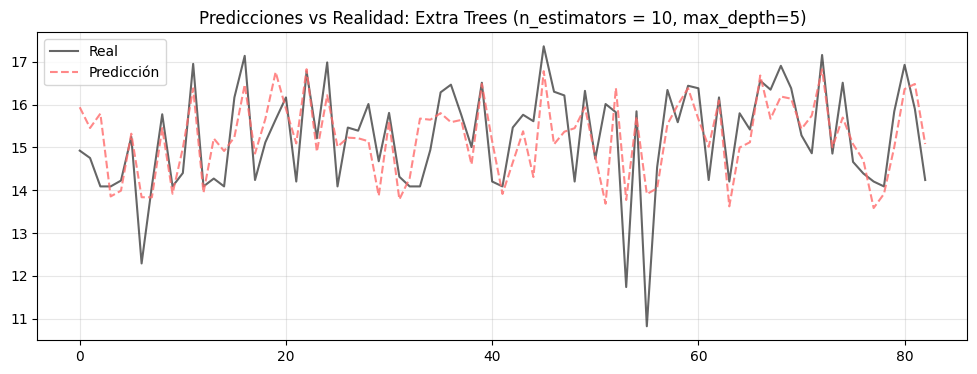

Modelo: Extra Trees (n_estimators = 100, max_depth=5) entrenado y evaluado en 0.57 segundos.


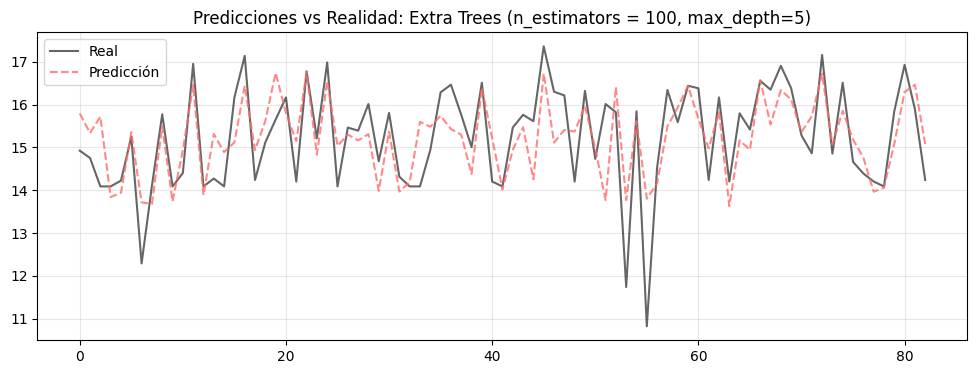

Modelo: Extra Trees (n_estimators = 200, max_depth=5) entrenado y evaluado en 1.07 segundos.


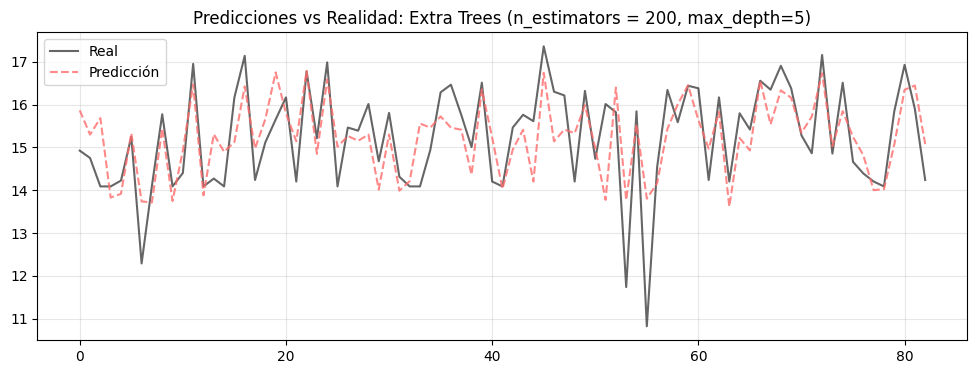

Modelo: Extra Trees (n_estimators = 10, max_depth=10) entrenado y evaluado en 0.14 segundos.


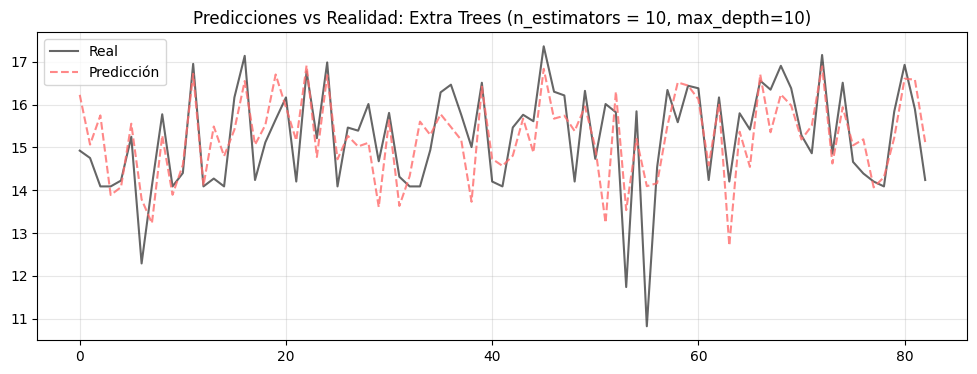

Modelo: Extra Trees (n_estimators = 100, max_depth=10) entrenado y evaluado en 0.96 segundos.


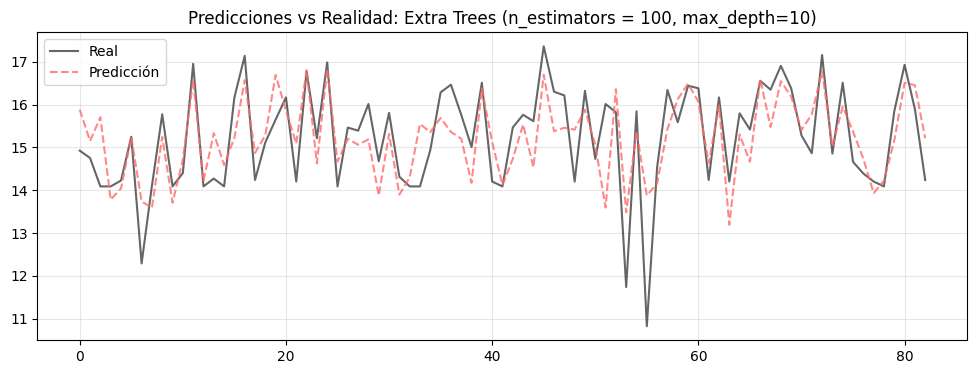

Modelo: Extra Trees (n_estimators = 200, max_depth=10) entrenado y evaluado en 1.98 segundos.


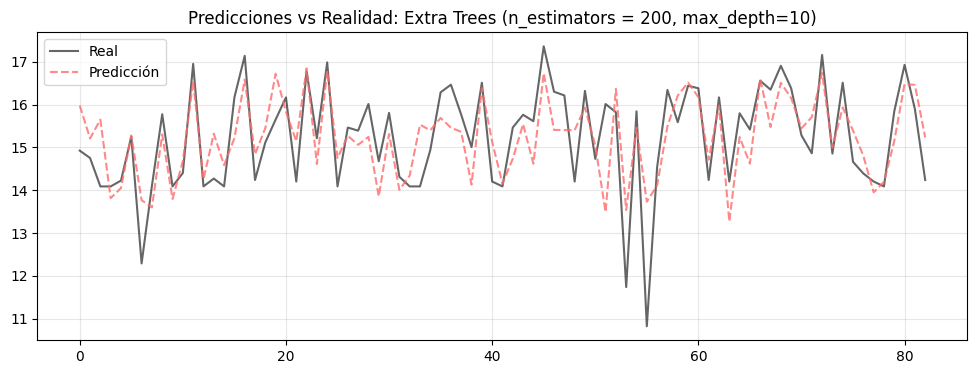

Modelo: SVR (Linear Kernel) (C=1, epilson=.1) entrenado y evaluado en 0.14 segundos.


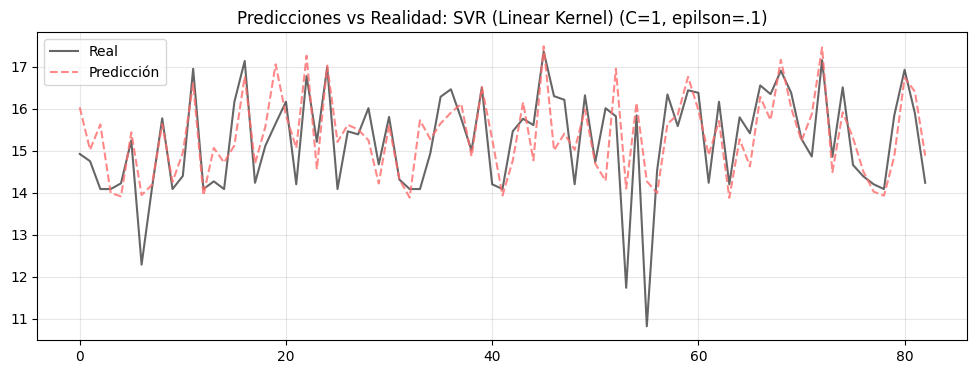

Modelo: SVR (Linear Kernel) (C=10, epilson=.1) entrenado y evaluado en 1.34 segundos.


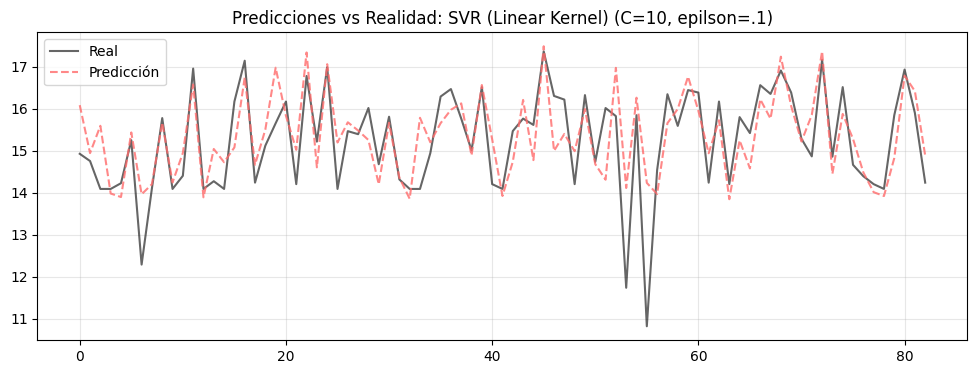

Modelo: SVR (Linear Kernel) (C=10, epilson=.1, gamma=scale) entrenado y evaluado en 0.81 segundos.


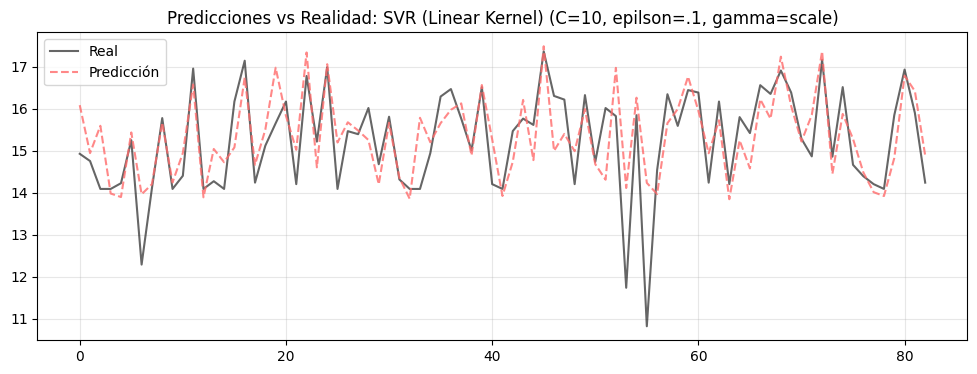

Modelo: Gradient Boosting entrenado y evaluado en 0.97 segundos.


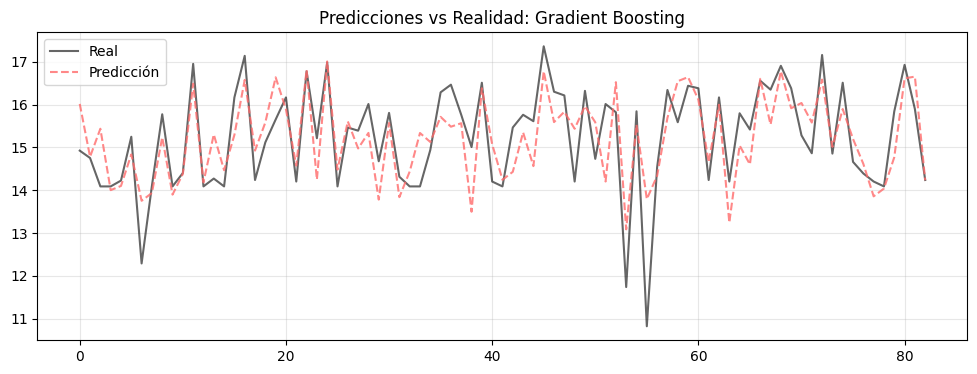

Modelo: Gradient Boosting (n_estimators=200) entrenado y evaluado en 2.02 segundos.


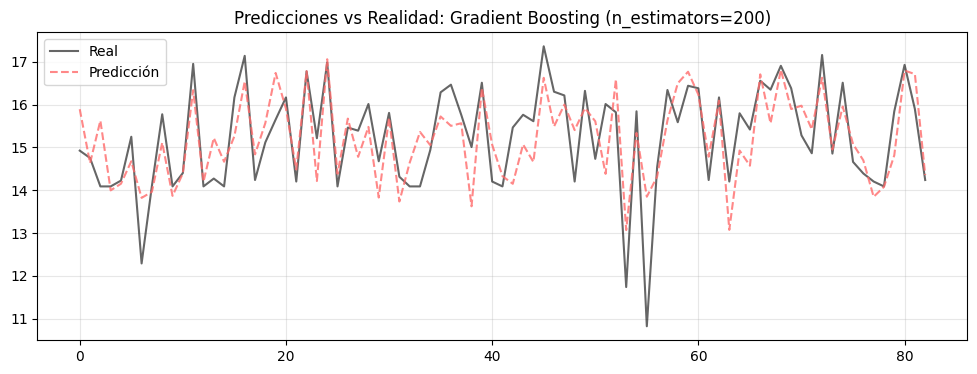

Modelo: Gradient Boosting (learning_rate=0.05) entrenado y evaluado en 0.97 segundos.


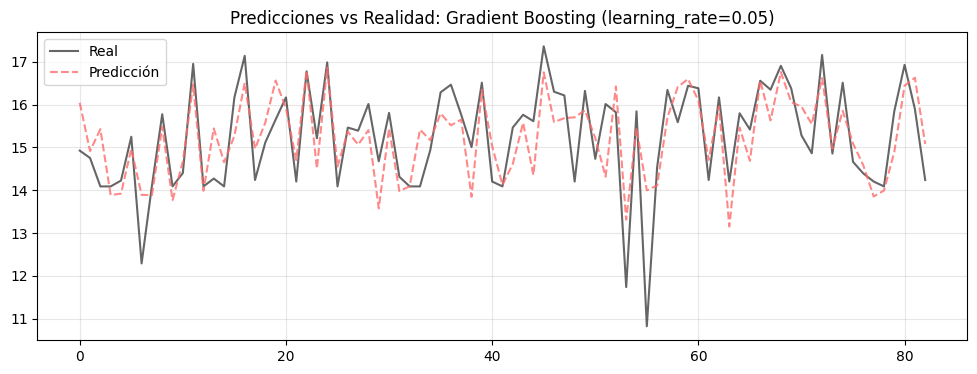

Modelo: Gradient Boosting (max_depth=5) entrenado y evaluado en 1.64 segundos.


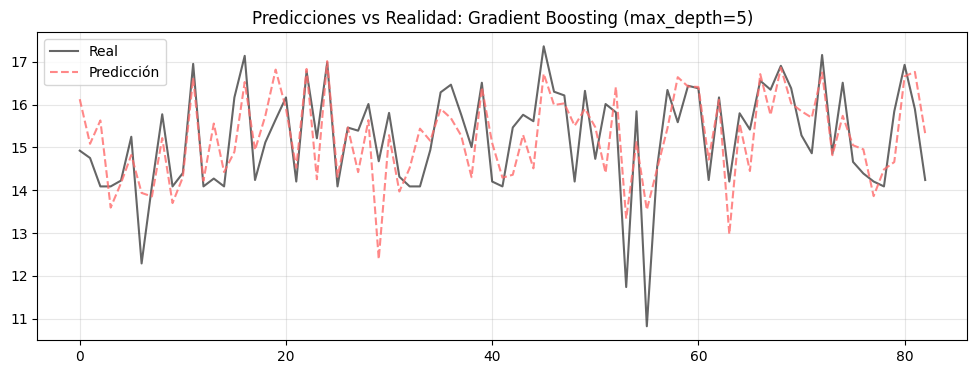

Modelo: HistGradient Boosting entrenado y evaluado en 3.13 segundos.


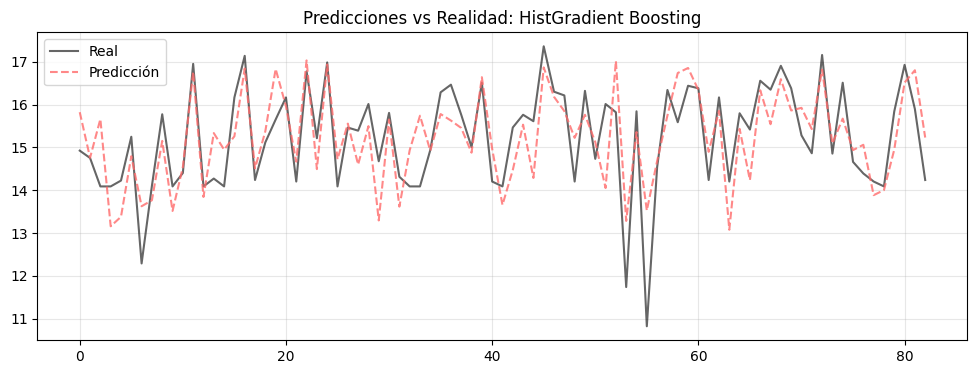

Modelo: HistGradient Boosting (learning_rate=0.05) entrenado y evaluado en 3.00 segundos.


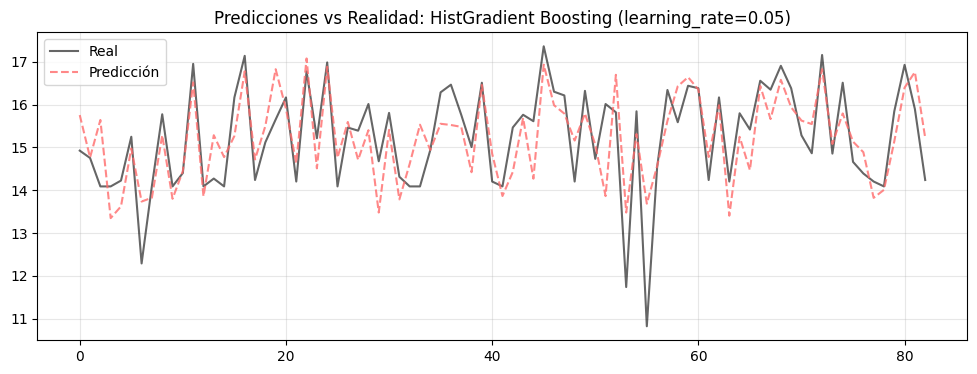

Modelo: HistGradient Boosting (max_depth=5) entrenado y evaluado en 2.01 segundos.


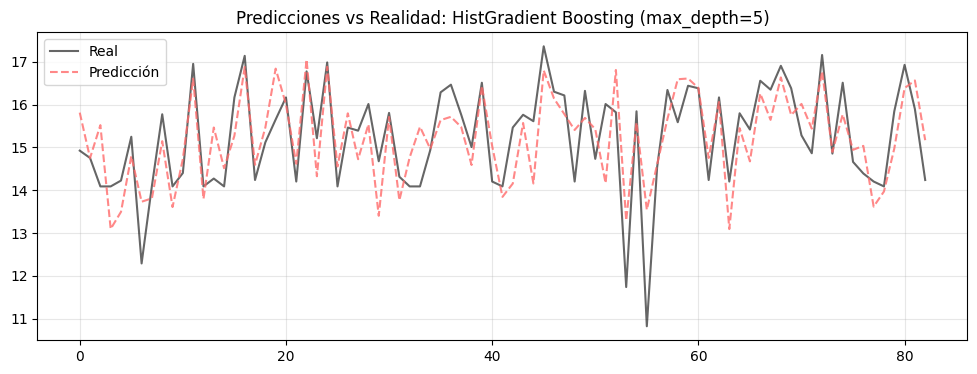

Modelo: XGBoost entrenado y evaluado en 1.86 segundos.


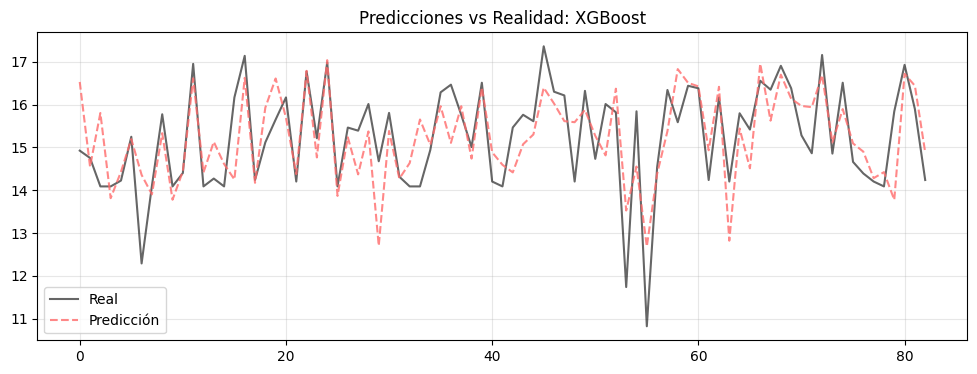

Modelo: XGBoost (n_estimators=200) entrenado y evaluado en 2.35 segundos.


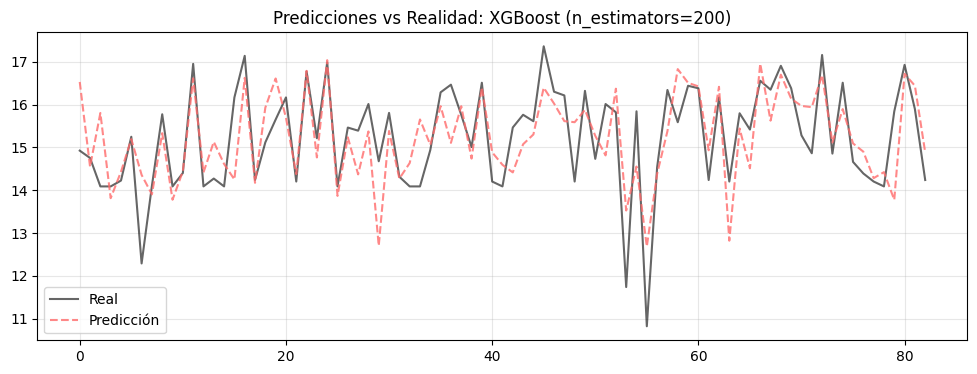

Modelo: XGBoost (learning_rate=0.05) entrenado y evaluado en 2.00 segundos.


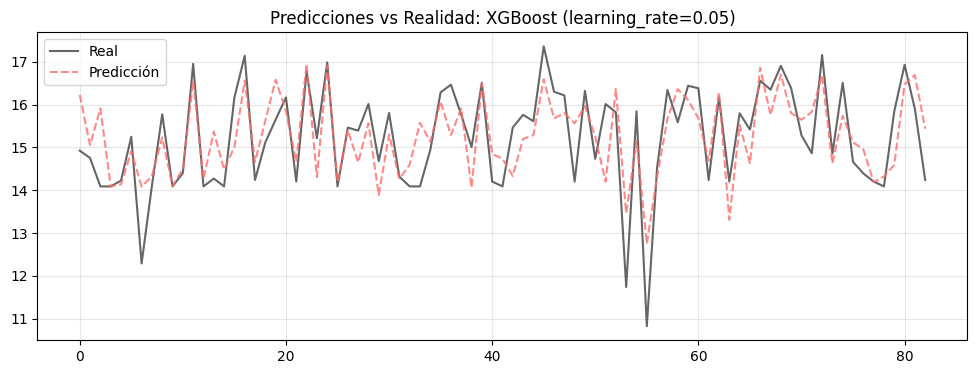

Modelo: XGBoost (max_depth=5) entrenado y evaluado en 1.66 segundos.


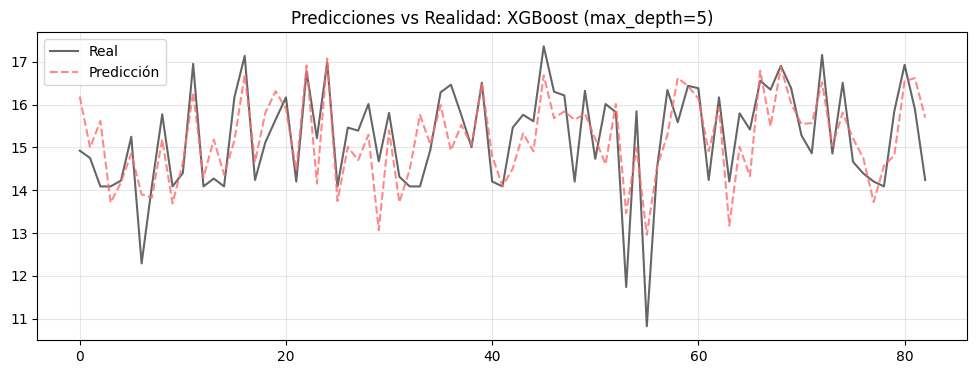

Modelo: LightGBM entrenado y evaluado en 1.84 segundos.


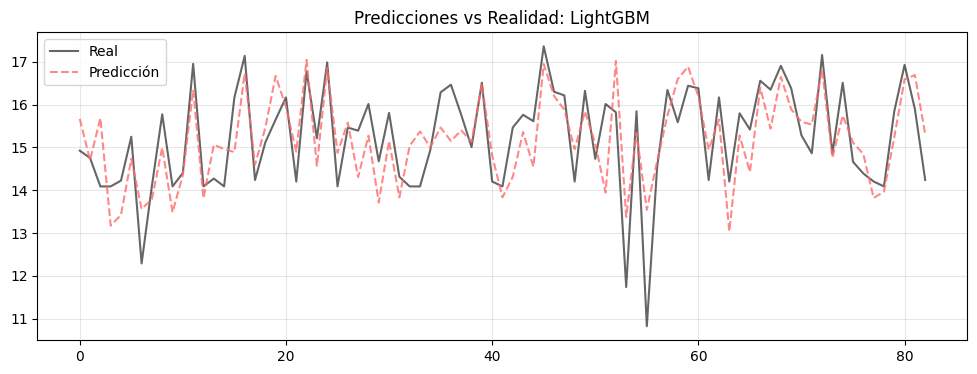

Modelo: LightGBM (n_estimators=200) entrenado y evaluado en 3.38 segundos.


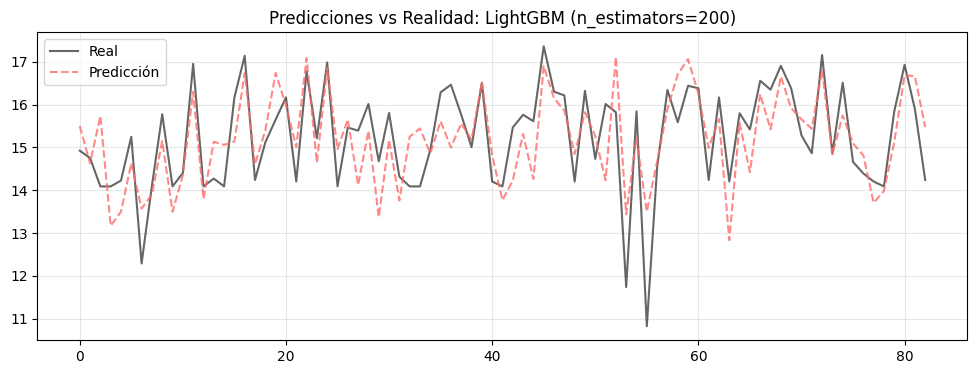

Modelo: LightGBM (learning_rate=0.05) entrenado y evaluado en 1.71 segundos.


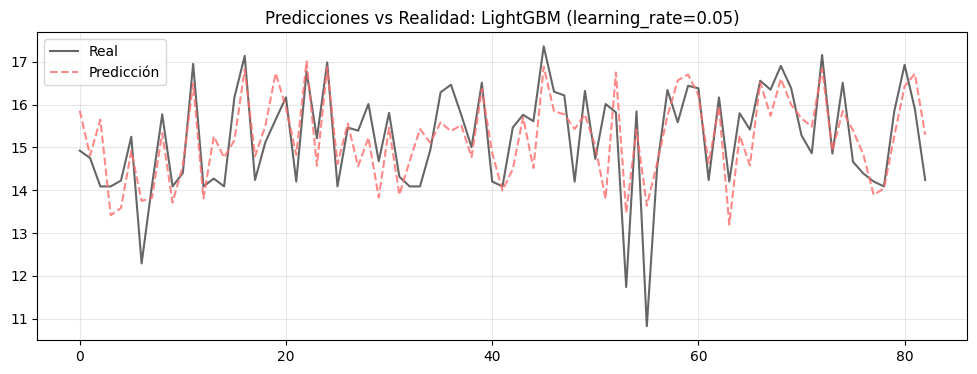

Modelo: LightGBM (max_depth=5) entrenado y evaluado en 1.34 segundos.


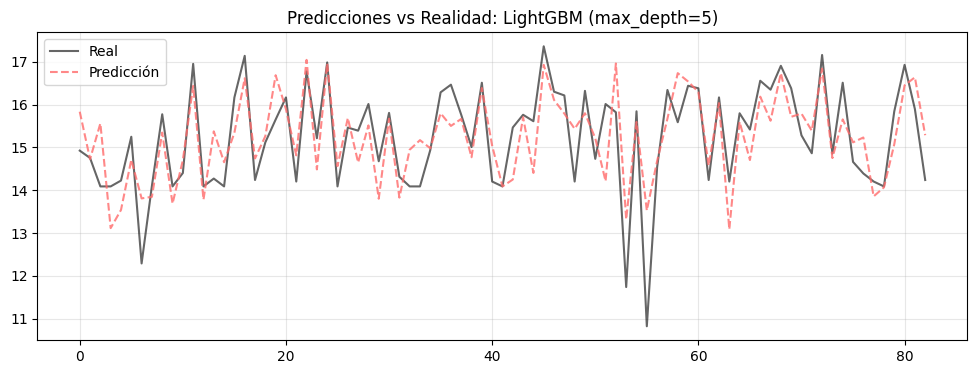

Comparativa de Modelos Predictivos para Predecir Salarios de Jugadores de la NBA:


,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
43,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
1,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
2,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
3,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
4,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
5,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
6,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165
7,Random Forest (n_estimators = 100),0.914646,0.468021,0.774458,0.586108
8,HistGradient Boosting (learning_rate=0.05),0.945813,0.427953,0.775323,0.585183


In [ ]:



models_to_test = {
    "LinearRegression": LinearRegression(), # Lineal Baseline
    # LASSO
    "Lasso Regression (alpha=0.001)": Lasso(alpha=0.001),
    "Lasso Regression (alpha=0.01)": Lasso(alpha=0.01),
    "Lasso Regression (alpha=0.1)": Lasso(alpha=0.1),

    # DECISION TREE
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Decision Tree (max_depth=5)": DecisionTreeRegressor(random_state=42, max_depth=5),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(random_state=42, max_depth=10),

    # RANDOM FOREST
    "Random Forest (n_estimators = 10)": RandomForestRegressor(n_estimators=10, random_state=42),
    "Random Forest (n_estimators = 100)": RandomForestRegressor(n_estimators=100, random_state=42),
    "Random Forest (n_estimators = 200)": RandomForestRegressor(n_estimators=200, random_state=42),
    "Random Forest (n_estimators = 10, max_depth=5)": RandomForestRegressor(n_estimators=10, random_state=42, max_depth=5),
    "Random Forest (n_estimators = 100, max_depth=5)": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
    "Random Forest (n_estimators = 200, max_depth=5)": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=5),
    "Random Forest (n_estimators = 10, max_depth=10)": RandomForestRegressor(n_estimators=10, random_state=42, max_depth=10),
    "Random Forest (n_estimators = 100, max_depth=10)": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "Random Forest (n_estimators = 200, max_depth=10)": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10),


    # EXTRA TREES
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Extra Trees (n_estimators = 10)": ExtraTreesRegressor(n_estimators=10, random_state=42),
    "Extra Trees (n_estimators = 100)": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Extra Trees (n_estimators = 200)": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "Extra Trees (n_estimators = 10, max_depth=5)": ExtraTreesRegressor(n_estimators=10, random_state=42, max_depth=5),
    "Extra Trees (n_estimators = 100, max_depth=5)": ExtraTreesRegressor(n_estimators=100, random_state=42, max_depth=5),
    "Extra Trees (n_estimators = 200, max_depth=5)": ExtraTreesRegressor(n_estimators=200, random_state=42, max_depth=5),
    "Extra Trees (n_estimators = 10, max_depth=10)": ExtraTreesRegressor(n_estimators=10, random_state=42, max_depth=10),
    "Extra Trees (n_estimators = 100, max_depth=10)": ExtraTreesRegressor(n_estimators=100, random_state=42, max_depth=10),
    "Extra Trees (n_estimators = 200, max_depth=10)": ExtraTreesRegressor(n_estimators=200, random_state=42, max_depth=10),

    # SVM REGRESSOR 
    "SVR (Linear Kernel) (C=1, epilson=.1)": SVR(kernel='linear', C=1, epsilon=.1),
    "SVR (Linear Kernel) (C=10, epilson=.1)": SVR(kernel='linear', C=10, epsilon=.1),
    "SVR (Linear Kernel) (C=10, epilson=.1, gamma=scale)": SVR(kernel='linear', C=10, epsilon=.1, gamma='scale'),

    # GRADIENT BOOSTING
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3),
    "Gradient Boosting (n_estimators=200)": GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=3),
    "Gradient Boosting (learning_rate=0.05)": GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=3),
    "Gradient Boosting (max_depth=5)": GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5),

    # HistGradient Boosting 
    "HistGradient Boosting": HistGradientBoostingRegressor(random_state=42), 
    "HistGradient Boosting (learning_rate=0.05)": HistGradientBoostingRegressor(random_state=42, learning_rate=0.05),
    "HistGradient Boosting (max_depth=5)": HistGradientBoostingRegressor(random_state=42, max_depth=5),

    #  XGBOOST
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "XGBoost (n_estimators=200)": XGBRegressor(n_estimators=200, random_state=42),
    "XGBoost (learning_rate=0.05)": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    "XGBoost (max_depth=5)": XGBRegressor(n_estimators=100, max_depth=5, random_state=42),

    # LIGHTGBM
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    "LightGBM (n_estimators=200)": LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    "LightGBM (learning_rate=0.05)": LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1),
    "LightGBM (max_depth=5)": LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, verbose=-1),
}

for model_name, model in models_to_test.items():
    start_time = time.time()
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('model', model)])
    # Validación cruzada en el conjunto de entrenamiento, obtenemos RMSE y R2 con la misma estructura
    cv_results = cross_validate(pipeline, X_train, y_train,
                                scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}, cv=10)
    rmse_train_cv = -cv_results['test_rmse'].mean()
    r2_train_cv = cv_results['test_r2'].mean()

    # Entrenamiento final en todo el conjunto de entrenamiento y test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # metricas en el conjunto de test
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)
    # Añadimos los resultados al DataFrame comparativo
    model_comparative = add_model(model_comparative, model_name, rmse_train_cv, r2_train_cv, rmse_test, r2_test)
    end_time = time.time()
    print(f"Modelo: {model_name} entrenado y evaluado en {end_time - start_time:.2f} segundos.")
    visualize_predictions(y_test, y_pred, model_name)

print("Comparativa de Modelos Predictivos para Predecir Salarios de Jugadores de la NBA:")
display(model_comparative)

## Análisis y Comparativa de los modelos predictivos

Los mejores modelos para la predicción del salario de jugadores de la NBA son aquellos que logran un equilibrio entre precisión y capacidad de generalización. A continuación, se presentan los modelos más destacados:
1. Gradient Boosting
2. LightGBM (max_depth=5)
3. XGBoost (learning_rate=0.05)

Tienen un RMSE test en torno al 0.761-0.762, lo que indica que, en promedio, las predicciones del modelo se desvían en aproximadamente 0.761 unidades logarítmicas del salario real. Esto se traduce en una desviación significativa cuando se convierte de nuevo a la escala original de salarios, pero es un buen resultado considerando la complejidad y variabilidad inherente en los datos de salarios de la NBA.

## Fine Tunning de Modelos Predictivos (Grid Search)

De todos los modelos probados optimizamos los hiperparámetros de los modelos que mejor rendimiento han tenido.


Mejores hiperparámetros encontrados:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Rendimiento del mejor modelo en el conjunto de prueba: RMSE = 0.7719, R2 = 0.5889


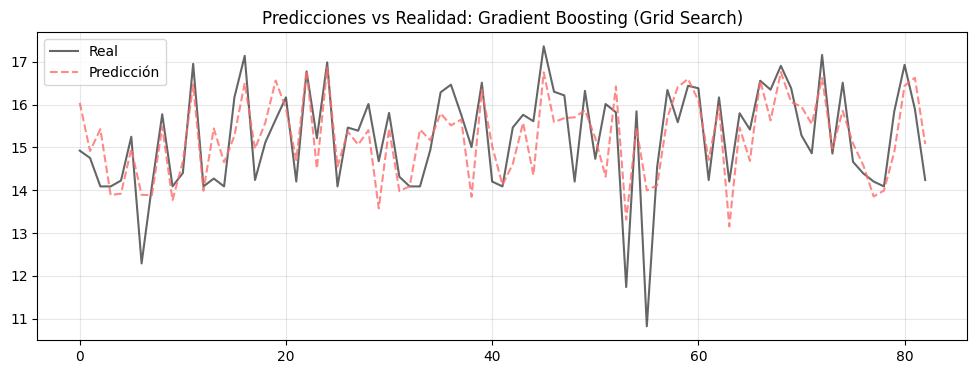

,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
1,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
2,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
3,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
4,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
5,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
44,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
6,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
7,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165
8,Random Forest (n_estimators = 100),0.914646,0.468021,0.774458,0.586108


In [ ]:
grid_searcg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('model', GradientBoostingRegressor(random_state=42))])


param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(grid_searcg_pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
# cv = 5 evalua 5 veces cada combinación de hiperparámetros
# n_jobs = -1 usa todos los núcleos disponibles para acelerar el proceso
# verbose = -1 silencia la salida de logs para no saturar la consola
# scoring = 'neg_root_mean_squared_error' optimiza para minimizar el RMSE
grid_search.fit(X_train, y_train)


print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

#Evaluamos el mejor modelo encontrado
y_pred_best = grid_search.predict(X_test)
rmse_test_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_test_best = r2_score(y_test, y_pred_best)

# RMSE del Cross-Validation (de negativo a positivo)
rmse_train_cv_best = -grid_search.best_score_
r2_train_cv_best = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5, scoring='r2').mean()

print(f"Rendimiento del mejor modelo en el conjunto de prueba: RMSE = {rmse_test_best:.4f}, R2 = {r2_test_best:.4f}")

model_comparative = add_model(model_comparative, "Gradient Boosting (Grid Search)", rmse_train_cv_best, r2_train_cv_best, rmse_test_best, r2_test_best)

visualize_predictions(y_test, y_pred_best, "Gradient Boosting (Grid Search)")


display(model_comparative)

## Análisis de resultados tras el Fine Tunning

A través de Fine Tunning hemos intentado mejorar el rendieminto del modelo Gradient Boosting, que ya era el mejor modelo antes del ajuste de hiperparámetros.

Al realizar los ajustes y definir varios hiperparámetros, este modelo ha queado en 7º posición en la tabla de resultados, con un RMSE test de 0.771869, en cambio el mejor modelo (Gradient Boosting sin tunning) tenía un RMSE test de 0.761.

El modelo ganador ha sido "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3), y con el fine tunning hemos empeorado el rendimiento del modelo.
Esto se debe a que los hiperparámetros seleccionados no han sido los óptimos para este dataset en particular, y el modelo ha perdido capacidad de generalización al ajustarse demasiado a los datos de entrenamiento durante el proceso de búsqueda en cuadrícula (Grid Search).

Ya que hemos visto que realizando la optimización de hiperparámetros no hemos mejorado el rendimiento del modelo, podemos hacer uso de la técnica "Ensemble Voting", esto consta en combinar las predicciones de varios modelos para mejorar la precisión y robustez de las predicciones finales.

En vez de intentar optimizar un solo modelo, combinamos las predicciones de varios modelos fuertes (Gradient Boosting, LightGBM y XGBoost) para aprovechar sus fortalezas individuales y compensar sus debilidades.


## Ensamble Voting 

Vamos a definir un ensamble de votación (Voting Regressor) que combine las predicciones de los tres mejores modelos identificados previamente: 
- Gradient Boosting
-  LightGBM
-  XGBoost

Esto se basa en promediar las predicciones de los mejores modelos para obtener una predicción final más robusta y estable.

Entrenando Voting Regressor (GB + LGBM + XGB  )
RMSE Voting Model: 0.7399
R2 Voting Model: 0.6222


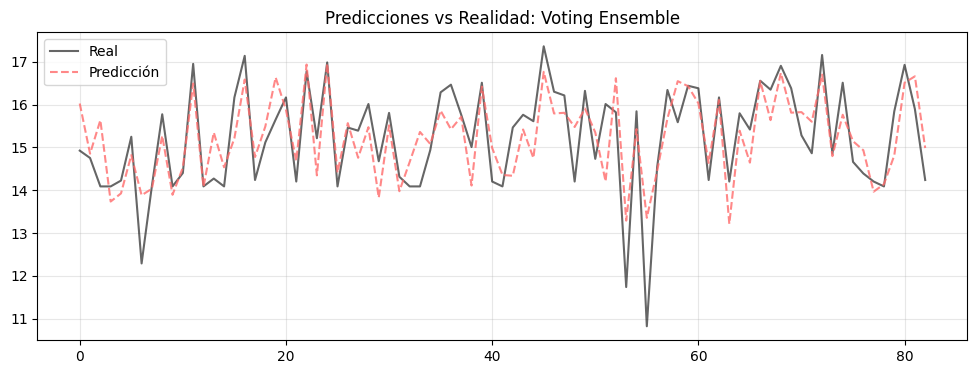

,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
45,Voting Ensemble (Top 3),0.913627,0.467918,0.739922,0.622198
0,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
1,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
2,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
3,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
4,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
5,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
6,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
7,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
8,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165


In [35]:
model_1 = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3) # "Gradient Boosting":  El ganador
model_2 = LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, verbose=-1) # "LightGBM (max_depth=5)":  El subcampeón
model_3 = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42) # "XGBoost (learning_rate=0.05)": El tercero

voting_reg = VotingRegressor(
    estimators=[
        ('gb', model_1),
        ('xgb', model_2),
        ('lgbm', model_3)
    ]
)

voting_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('voting', voting_reg)])

print("Entrenando Voting Regressor (GB + LGBM + XGB  )")
voting_pipeline.fit(X_train, y_train)

# 4. Evaluación
y_pred_voting = voting_pipeline.predict(X_test)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
r2_voting = r2_score(y_test, y_pred_voting)

print(f"RMSE Voting Model: {rmse_voting:.4f}")
print(f"R2 Voting Model: {r2_voting:.4f}")


r2_cv_voting = cross_val_score(voting_pipeline, X_train, y_train, cv=10, scoring='r2').mean()
rmse_cv_voting = -cross_val_score(voting_pipeline, X_train, y_train, cv=10, scoring='neg_root_mean_squared_error').mean()

model_comparative = add_model(model_comparative, "Voting Ensemble (Top 3)", rmse_cv_voting, r2_cv_voting, rmse_voting, r2_voting)
visualize_predictions(y_test, y_pred_voting, "Voting Ensemble")

display(model_comparative.sort_values(by='RMSE Test'))

Observamos que el modelo de ensamble Voting Regressor ha logrado un RMSE test de 0.7399, mejorando ligeramente el rendimiento del mejor modelo individual de los 3 modelos definidos. Esto confirma que combinar las predicciones de varios modelos fuertes puede ayudar a reducir el error y mejorar la capacidad de generalización del modelo final.

Esta técnica es bastante útil y signigica que el Ensamble Voting Regressor ha corregido los sesgos individuales de cada modelo, aprovechando sus fortalezas y compensando sus debilidades. Básicamente ha encontrado patrones que los modelos individuales no capturaron por sí solos.

Para que nuestro cliente pueda interpretar mejor el rendiemiento del modelo vamos a ver que features (características) hacen que un jugador tenga un salario más elevado según el modelo de ensamble Voting Regressor.

## Análsis de los factores más importantes según el modelo predictivo final
Accedemos a los modelos entrenados dentro del VotingRegressor que guarda sus modelos hijos en el atributo 'estimators_' en el siguiente  orden:
    - [0]=GradientBoosting
    - [1]=LightGBM
    - [2]=XGBoost
Obtenemos nombres de las columnas tras el OneHotEncoding para poder interpretar mejor los resultados de importancia de features.
Extraemos las importancias de las features de cada modelo y las combinamos para obtener una visión global de los factores que más influyen en la predicción del salario según el modelo de ensamble Voting Regressor.

In [ ]:

models_in_voting = voting_pipeline.named_steps['voting'].estimators_

preprocessor_step = voting_pipeline.named_steps['preprocessor']

num_names = list(numeric_features)

cat_names = preprocessor_step.named_transformers_['cat'].get_feature_names_out(categorical_features)

feature_names = num_names + list(cat_names)

avg_importance = np.mean([
    models_in_voting[0].feature_importances_, # Gradient Boosting
    models_in_voting[1].feature_importances_, # LGBMRegressor
    models_in_voting[2].feature_importances_  # XGBRegressor
], axis=0)


df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)


fig = px.bar(df_importance.head(12), x='Importance', y='Feature', orientation='h',
                title='Top 12 Factores que determinan el Salario NBA (Según Voting Model)',
                color='Importance', color_continuous_scale='Viridis')
fig.update_layout(yaxis=dict(autorange="reversed")) # Para que el #1 salga arriba
fig.show()

residuals = y_test - y_pred_voting

fig_res = px.scatter(x=y_pred_voting, y=residuals,
                        labels={'x': 'Salario Predicho (Log)', 'y': 'Error (Residuo)'},
                        title='Análisis de Residuos: ¿Hay patrones en nuestros errores?')
# Línea de error cero
fig_res.add_hline(y=0, line_dash="dash", line_color="red")
fig_res.show()

## Conclusiones

Observamos que el modelo de ensamble Voting Regressor ha logrado un RMSE test de 0.7399, mejorando ligeramente el rendimiento del mejor modelo individual de los 3 modelos definidos. Esto confirma que combinar las predicciones de varios modelos fuertes puede ayudar a reducir el error y mejorar la capacidad de generalización del modelo final.

## Feature Importance - Análisis de características más importantes según el modelo predictivo final
El gráfico de barras muestra la importancia relativa de cada característica (feature) en la predicción del salario según el modelo de ensamble Voting Regressor. Las características con barras más largas tienen un mayor impacto en las predicciones del modelo. Se puede decir que en base a estas características, el modelo toma decisiones para estimar el salario de los jugadores de la NBA.
Las características más importantes según el modelo son:
 - Age (Edad): La edad del jugador es un factor crucial. Los jugadores en su pico de rendimiento (25-30 años) tienden a tener salarios más altos, ya que están en la etapa óptima de su carrera.
 - PTS (Puntos): La capacidad de anotar puntos es fundamental. Los jugadores que contribuyen significativamente al marcador suelen recibir salarios más altos. Se paga mejor cuanto mejor sea la capacidad anotadora del jugador.
 - G (Partidos Jugados): Cuanto más tiempo juegue un jugador, mayor será su salario. Esto refleja la confianza del equipo en el jugador y su importancia en la rotación.


## Análisis de residuos del modelo predictivo final

Este gráfico de residuos muestra la distribución (errores vs predicciones) de los errores del modelo de ensamble Voting Regressor. 

Eje X: Predicciones del modelo (log-salary), salario predicho por el modelo.
Eje Y: Residuos (Errores), diferencia entre el salario real y el salario predicho. (Salario Real - Salario Predicho)
Linea Horizontal en Y=0: Indica predicciones perfectas (sin error). Si una predicción cae en esta línea, significa que el modelo predijo exactamente el salario real del jugador.

- Puntos por encima de la linea horizontal Y = 0:
  - Real > Predicho, significa que el jugdor cobra más de lo que dicen los datos/estadísticas.
  - Interpretación: Son jugadores sobrepagados en relación a sus estadisticas (rendimiento). El modelo no puede justificar su salario basándose en las métricas disponibles.
  - Estos jugadores podrían ser estrellas del marketing, tener contratos garantizados, ser veteranos con salarios altos por su experiencia,liderazgo en el vestuario, etc.
- Puntos por debajo de la linea horizontal Y = 0:
  - Real < Predicho, significa que el jugador cobra menos de lo que dicen los datos/estadísticas.
  - Interpretación: Son jugadores infravalorados en relación a sus estadisticas (rendimiento). El modelo predice que deberían ganar más basándose en sus métricas.
  - Estos jugadores podrían ser jóvenes con potencial, jugadores en equipos con restricciones salariales, o aquellos que aún no han negociado contratos acorde a su rendimiento.

- Patrón de Residuos:
  - Lo ideal es tener una nube aleatoria sin forma definida centrad en el 0, indica buen ajuste del modelo y que no hay patrones sistemáticos en los errores.
  - Si vemos un "embudo" o una "curva" significa que el modelo falla en ciertas regiones (por ejemplo, predice mal para salarios muy altos o muy bajos).
En resumen, este gráfico nos ayuda a entender dónde el modelo funciona bien y dónde podría mejorar, observamos que tenemos una nube aleatoria de residuos centrada en 0, lo que indica que el modelo tiene un buen ajuste y no presenta patrones sistemáticos en los errores de predicción. Por lo que podemos concluir que el modelo es adecuado para predecir los salarios de los jugadores de la NBA basándose en las métricas disponibles.


Podemos concluir que los modelos de machine learning han sido efectivos para predecir los salarios de los jugadores de la NBA basándose en sus estadísticas y características. El modelo de ensamble Voting Regressor ha demostrado ser el más robusto, logrando un buen equilibrio entre precisión y capacidad de generalización.

Rendimiento del modelo:
 - El modelo de ensamble Voting Regressor ha logrado un RMSE test de 0.7399, mejorando ligeramente el rendimiento del mejor modelo individual. Esto indica que combinar las predicciones de varios modelos fuertes puede ayudar a reducir el error y mejorar la capacidad de generalización del modelo final. Combina los modelos Gradient Boosting, LightGBM y XGBoost.
 - Es importante entender a que características (features) hacen que un jugador tenga un salario más elevado según el modelo de ensamble Voting Regressor, para que nuestro cliente pueda interpretar mejor el rendiemiento del modelo y también pueda tomar decisiones informadas sobre la gestión de su plantilla y las negociaciones salariales.
 - Las características más importantes según el modelo son:
    - Age (Edad): La edad del jugador es un factor crucial. Los jugadores en su pico de rendimiento (25-30 años) tienden a tener salarios más altos, ya que están en la etapa óptima de su carrera.
    - PTS (Puntos): La capacidad de anotar puntos es fundamental. Los jugadores que contribuyen significativamente al marcador suelen recibir salarios más altos. Se paga mejor cuanto mejor sea la capacidad anotadora del jugador.
    - G (Partidos Jugados): Cuanto más tiempo juegue un jugador, mayor será su salario. Esto refleja la confianza del equipo en el jugador y su importancia
- Análisis de residuos:
    -  El gráfico de residuos muestra una distribución homogénea, lo que valida el modelo. Sin embargo, existen outliers (puntos alejados de la línea roja). Estos representan jugadores que cobran mucho más (o menos) de lo que sus estadísticas sugieren, probablemente debido a factores intangibles (liderazgo, potencial de marketing) que los datos numéricos no capturan.

### ANN Sequence Model (Redes Neuronales - Deep Learning)

In [ ]:

X_train_ann = preprocessor.fit_transform(X_train)
X_test_ann = preprocessor.transform(X_test)

# Convertimos a denso si es disperso (sparse matrix)
if hasattr(X_train_ann, 'toarray'):
    X_train_ann = X_train_ann.toarray()
    X_test_ann = X_test_ann.toarray()


print(f"Dimensiones para ANN: X_train: {X_train_ann.shape}, X_test: {X_test_ann.shape}")

Dimensiones para ANN: X_train: (328, 21), X_test: (83, 21)


In [ ]:
def train_eval_ann(model, name, epochs = 100):
    model.compile(loss='mean_squared_error', optimizer='adam')
    history = model.fit(X_train_ann, y_train, validation_split=0.2, epochs=epochs, batch_size=32,
                        verbose=0) # verbose=0 para no saturar la consola

    mse_test = model.evaluate(X_test_ann, y_test, verbose=0)
    rmse_test = np.sqrt(mse_test)

    # predicciones para R2
    y_pred = model.predict(X_test_ann).flatten()
    r2_test = r2_score(y_test, y_pred)
    rmse_train = np.sqrt(history.history['loss'][-1])
    r2_train = 0.0 
    pd.DataFrame(history.history).plot(title=f'Entrenamiento ANN: {name}', figsize=(10, 6))
    plt.grid(True)
    plt.title(f'Curvas de Entrenamiento y Validación - {name}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida (MSE)')
    plt.show()

    return rmse_train, r2_train, rmse_test, r2_test



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


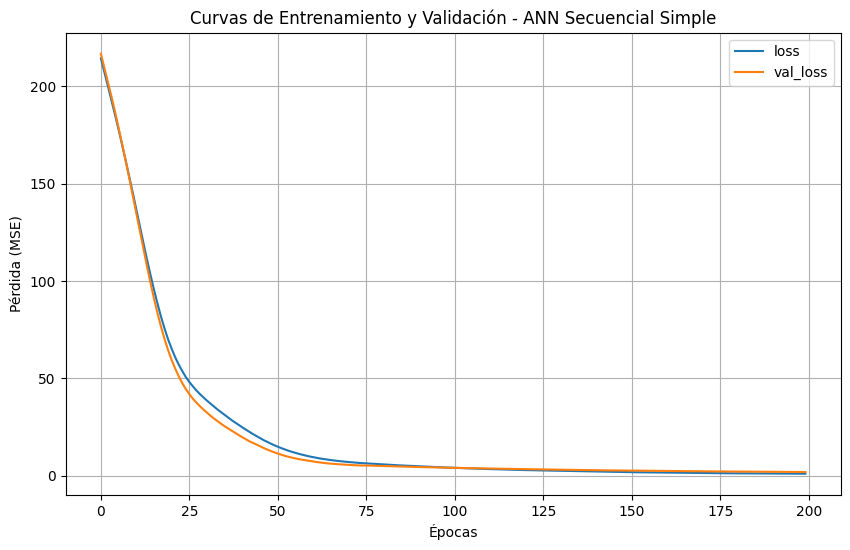

Modelo ANN: ANN Secuencial Simple evaluado. RMSE Test: 1.5041, R2 Test: -0.5612
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


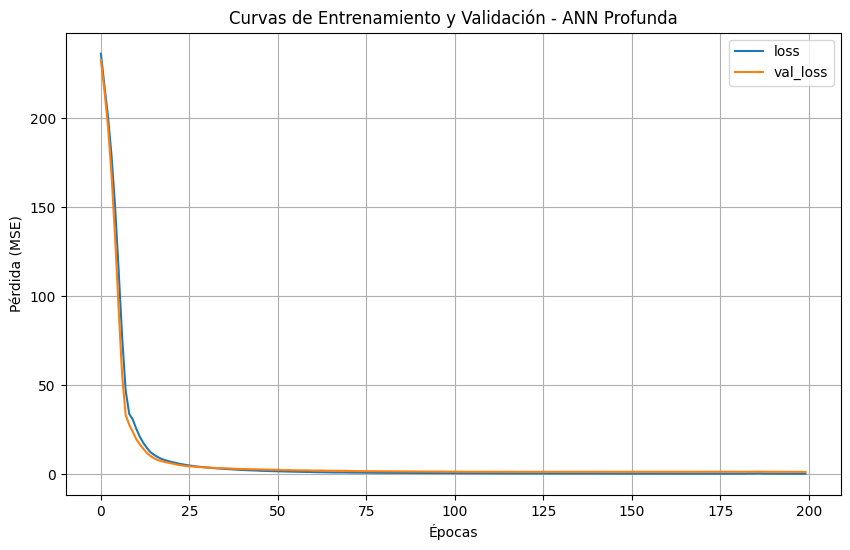

Modelo ANN: ANN Profunda evaluado. RMSE Test: 1.2968, R2 Test: -0.1604
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x12cf4ce00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


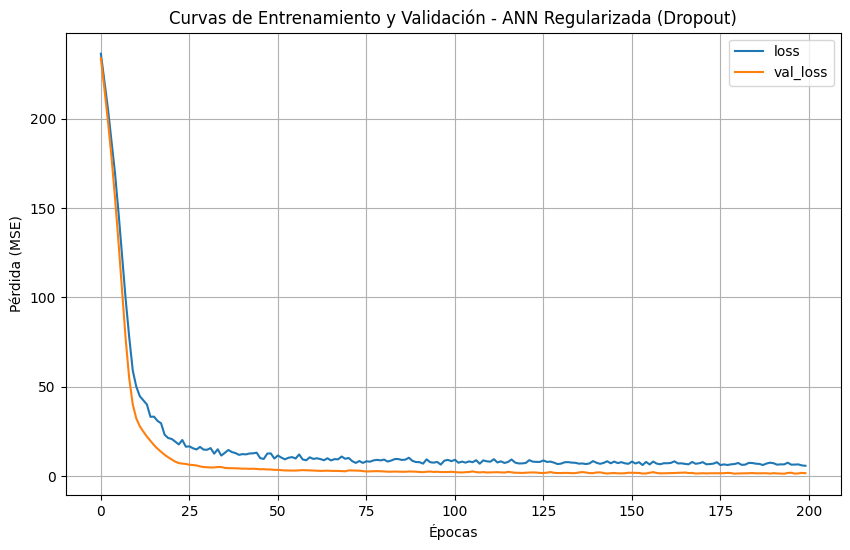

Modelo ANN: ANN Regularizada (Dropout) evaluado. RMSE Test: 1.2302, R2 Test: -0.0443


,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Voting Ensemble (Top 3),0.913627,0.467918,0.739922,0.622198
1,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
2,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
3,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
4,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
5,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
6,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
7,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
8,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
9,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165


In [ ]:
model_sequential = keras.models.Sequential([
    layers.Input(shape=X_train_ann.shape[1:]),
    layers.Dense(30, activation='relu'),
    layers.Dense(1)
], name='ANN_Sequential_Model')

model_deep = keras.models.Sequential([
    layers.Input(shape=X_train_ann.shape[1:]),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
], name='ANN_Deep_Model')

model_reg = keras.models.Sequential([
    layers.Input(shape=X_train_ann.shape[1:]),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Apaga el 30% de las neuronas aleatoriamente durante el entrenamiento
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
], name='ANN_Regularized_Model')


anns_to_test = {
    "ANN Secuencial Simple": model_sequential,
    "ANN Profunda": model_deep,
    "ANN Regularizada (Dropout)": model_reg
}

for ann_name, ann_model in anns_to_test.items():
    rmse_train_ann, r2_train_ann, rmse_test_ann, r2_test_ann = train_eval_ann(ann_model, ann_name, epochs=200)
    model_comparative = add_model(model_comparative, ann_name, rmse_train_ann, r2_train_ann, rmse_test_ann, r2_test_ann)
    print(f"Modelo ANN: {ann_name} evaluado. RMSE Test: {rmse_test_ann:.4f}, R2 Test: {r2_test_ann:.4f}")


display(model_comparative.sort_values(by='RMSE Test'))

## Comparación de los modelos de redes neuronales desarrollados

Las redes neuronales (ANN) para resolver el problema de predicción del salario de jugadores de la NBA no funciona mejor que los modelos de machine learning tradicionales (Gradient Boosting, XGBoost, LightGBM).
En la tabla comparativos de todos los modelos probados, observamos que están en las últimas posiciones, el hacer uso de ANN no implica que los resultados obtenidos sean mejores, ya que depende mucho del dataset y del problema a resolver.

Vamos a hacer uso de callbacks y fine tunning para intentar mejorar el rendimiento de las redes neuronales.

## Uso de Callbacks (Early Stopping) en Redes Neuronales

Hacer uso de redes neuronales implica que sea fácil sobreajustar el modelo a los datos de entrenamiento, por lo que es importante hacer uso de técnicas como Early Stopping para evitar este sobreajuste, esto significa que si nos pasamos con el número de épocas, el modelo empezará a memorizar los datos de entrenamiento y no generalizará bien a datos nuevos.
Ahora vamos ha hacer uso de callbacks que se trata de que en cada iteación (época de entrenamiento), se ejecuta una función que controla el rendimiento del modelo en un conjunto de validación. Si el rendimiento no mejora durante un número determinado de épocas (paciencia), el entrenamiento se detiene automáticamente para evitar el sobreajuste (overfitting). Mediante esta técnica se puede indicar la variable a monitorizar y que pacience debe tener el modelos para mejorar.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model_early_stop = keras.models.Sequential([
    layers.Input(shape=X_train_ann.shape[1:]),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'), 
    layers.Dense(1)
], name='ANN_Early_Stopping_Model')

model_early_stop.compile(loss='mean_squared_error', optimizer='adam')

history_early_stop = model_early_stop.fit(X_train_ann, y_train, 
                                            epochs=200,
                                            validation_split=0.2,
                                            callbacks=[callback], verbose=0)


In [41]:
ann_early_stop_mse_test = model_early_stop.evaluate(X_test_ann, y_test, verbose=0)
ann_early_stop_rmse_test = np.sqrt(ann_early_stop_mse_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step
Entrenamiento detenido en la época óptima tras 200 épocas.
Rendimiento del modelo con Early Stopping en el conjunto de prueba: RMSE = 1.3038, R2 = -0.1731


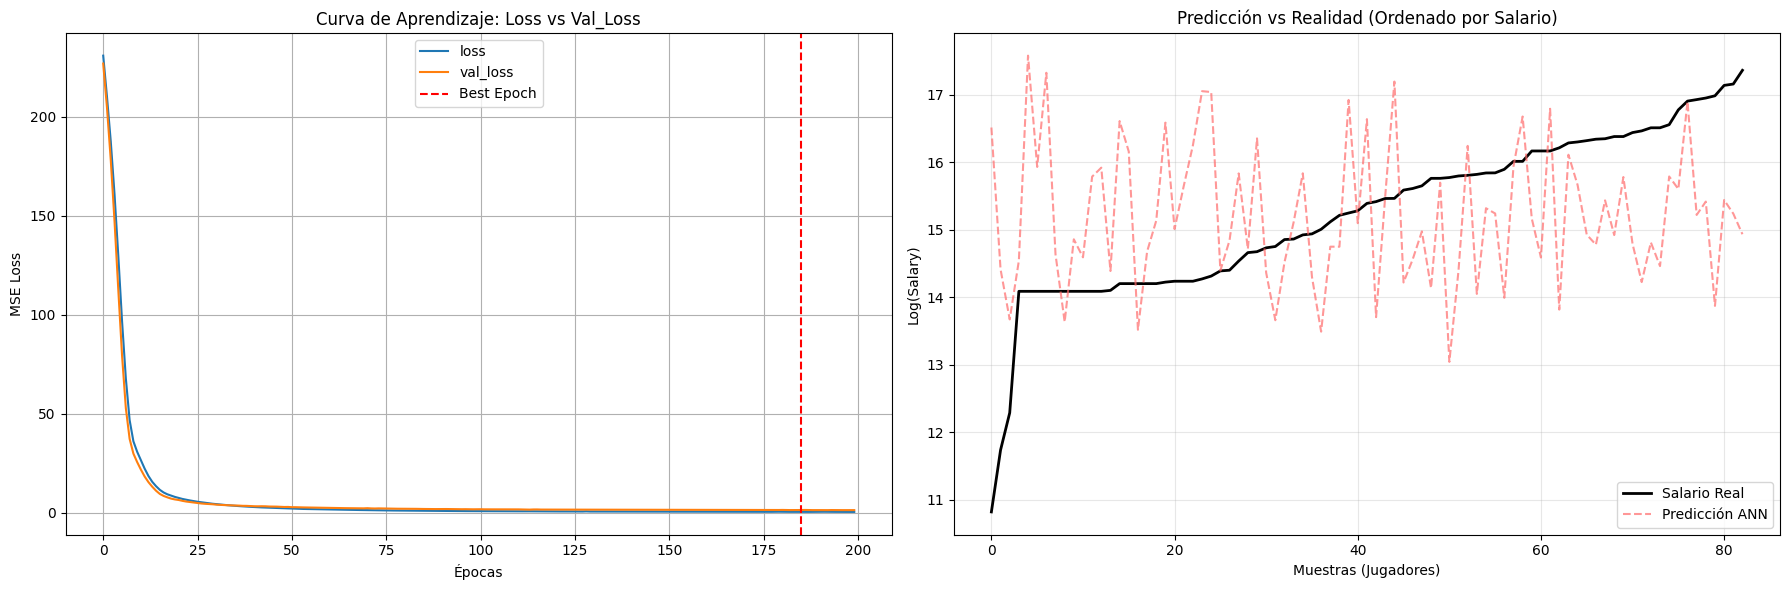

,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Voting Ensemble (Top 3),0.913627,0.467918,0.739922,0.622198
1,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
2,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
3,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
4,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
5,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
6,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
7,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
8,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
9,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165


In [42]:
# TEST
mse_test_early_stop = model_early_stop.evaluate(X_test_ann, y_test, verbose=0)
rmse_test_early_stop = np.sqrt(mse_test_early_stop)
y_pred_early_stop = model_early_stop.predict(X_test_ann).flatten()
r2_test_early_stop = r2_score(y_test, y_pred_early_stop)

# TRAIN (hacemos uso del ultimo valor del historial que corresponde a la última época entrenada, haciendo uso de restore_best_weights)
rmse_train_early_stop = np.sqrt(history_early_stop.history['loss'][-1])
y_pred_train_early_stop = model_early_stop.predict(X_train_ann).flatten()
r2_train_early_stop = r2_score(y_train, y_pred_train_early_stop)

print(f"Entrenamiento detenido en la época óptima tras {len(history_early_stop.history['loss'])} épocas.")
print(f"Rendimiento del modelo con Early Stopping en el conjunto de prueba: RMSE = {rmse_test_early_stop:.4f}, R2 = {r2_test_early_stop:.4f}")

model_comparative = add_model(model_comparative, "ANN con Early Stopping", rmse_train_early_stop, r2_train_early_stop, rmse_test_early_stop, r2_test_early_stop)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
pd.DataFrame(history_early_stop.history).plot(ax=ax[0])
# TEST Curva de aprendizaje (Earry Stopping)
ax[0].grid(True)
ax[0].set_title('Curva de Aprendizaje: Loss vs Val_Loss')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('MSE Loss')
# Marcamos el punto de parada óptimo
best_epoch = len(history_early_stop.history['loss']) - 15 # paciencia=15
if best_epoch > 0:
    ax[0].axvline(best_epoch, color='red', linestyle='--', label='Best Epoch')
    ax[0].legend()

# TRAIN Predicción vs Realidad (Scatter Plot es mejor que Line Plot para esto)
# Ordenamos los valores para que el gráfico de líneas tenga sentido visual
indices_ordenados = np.argsort(y_test.values)
y_test_sorted = y_test.values[indices_ordenados]
y_pred_sorted = y_pred_train_early_stop[indices_ordenados]

ax[1].plot(y_test_sorted, label='Salario Real', color='black', linewidth=2)
ax[1].plot(y_pred_sorted, label='Predicción ANN', color='#FF6B6B', alpha=0.7, linestyle='--')
ax[1].set_title('Predicción vs Realidad (Ordenado por Salario)')
ax[1].set_xlabel('Muestras (Jugadores)')
ax[1].set_ylabel('Log(Salary)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar tabla final
display(model_comparative.sort_values(by='RMSE Test'))



El objetivo es entrenar una red neuronal el tiempo suficiente para que aprenda patrones de los datos y detenerla antes de que empiece a memorizar el ruido o detalles específicos del conjunto de entrenamiento que no se generalizan bien a datos nuevos.

1. Grafica izquierda (Curva de aprendizaje del modelo con Early Stopping):
    - Tanto la pérdida de entrenamiento (Training Loss) como la pérdida de validación (Validation Loss) disminuyen inicialmente juntas hasta casi cero, lo que indica que el modelo está aprendiendo patrones útiles en los datos.
    - La línea roja discontinua está casi al final de las épocas de entrenamiento definidas (alrededor de la época 180), lo que indica que el modelo necesitá ver los datos muchas veces para converger.
2. Gráfica derecha (Predicciones vs Valores Reales):
    - La línea roja tiene numeros picos y valles, lo que indica que el modelo no está capturando bien la relación entre las características y el salario. (Debería ser más suave si el modelo fuera bueno).
    - En comparación con la gráfica del modelo ganador sin votos (Gradient Boosting), vemos que el modelo de ANN tiene más dispersión y no sigue tan bien la línea de los valores reales.
    - La red neuronal sufre una alta varianza en sus predicciones y causa de ello es que tenemos un dataset pequeño y no es capaz de trazar una curva suave que capture la relación entre las características y el salario. Reacciona de forma exagerada a pequeñas variaciones en los datos de entrada.

## Fine Tunning de Redes Neuronales (Grid Search)

Vamos a realizar un fine tunning de hiperparámetros para intentar mejorar el rendimiento de la red neuronal.
En el Deep Learning, el fine tunning de hiperparámetros es crucial para optimizar el rendimiento del modelo. A diferencia de los modelos tradicionales de machine learning, las redes neuronales tienen una gran cantidad de hiperparámetros que pueden afectar significativamente su capacidad para aprender patrones en los datos y pequeños cambios en estos hiperparámetros pueden tener un gran impacto en el rendimiento del modelo.

En lugar de probar a mano y con "prueba" y "error" utilizaremos la técinica Hyperparameter Optimization (HPO) que consiste en definir un espacio de búsqueda para los hiperparámetros y utilizar algoritmos de optimización (como Grid Search o Random Search) para explorar sistemáticamente este espacio y encontrar la combinación óptima de hiperparámetros que maximice el rendimiento del modelo en un conjunto de validación.

Vamos a implementar un proceso automatizado con RandomSearch que explora diferentes combinaciones de hiperparámetros dentro de un espacio definido y validando cuál de ellos ofrece el menor error en la validación.

1. Buscamos un equilibrio entre Underfitting y Overfitting:
    - Underfitting: El modelo no aprende lo suficiente de los datos (pérdida alta en entrenamiento y validación), pocas neuronas.
    - Overfitting: El modelo aprende demasiado bien los datos de entrenamiento, pero no generaliza a datos nuevos (pérdida baja en entrenamiento pero alta en validación), muchas neuronas.
    - Probaremos rangos entre 32 y 128 neuronas en la capa oculta para encontrar el punto óptimo.
2. Regularización (Dropout):
    - Ayuda a prevenir el overfitting al apagar aleatoriamente un porcentaje de neuronas durante el entrenamiento.
    - El sistema decide si es beneficioso o no apagar neruonas de forma aleatoria para forzar que la red aprenda mejor los patrones generales o robustos.
3. Velocidad de Aprendizaje (Learning Rate):
    - Controla qué tan rápido el modelo ajusta sus pesos durante el entrenamiento.
    - Un learning rate demasiado alto puede hacer que el modelo "salte" sobre los mínimos óptimos (haciendo que el modelo no converja), mientras que uno demasiado bajo puede hacer que el entrenamiento sea muy lento.
    - Probamos diferentes valores para encontrar el equilibrio adecuado.

Trial 10 Complete [00h 00m 03s]
val_loss: 4.994675636291504

Best val_loss So Far: 3.045985698699951
Total elapsed time: 00h 00m 31s

 Mejor modelo construido. Resumen:
Neuronas capa 1: 96
Learning Rate: 0.001
Usar Dropout: 0.0

--- Entrenando el modelo GANADOR con configuración robusta 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step
RMSE Test (Tuned): 14.2346 | R2 Test (Tuned): -138.8249


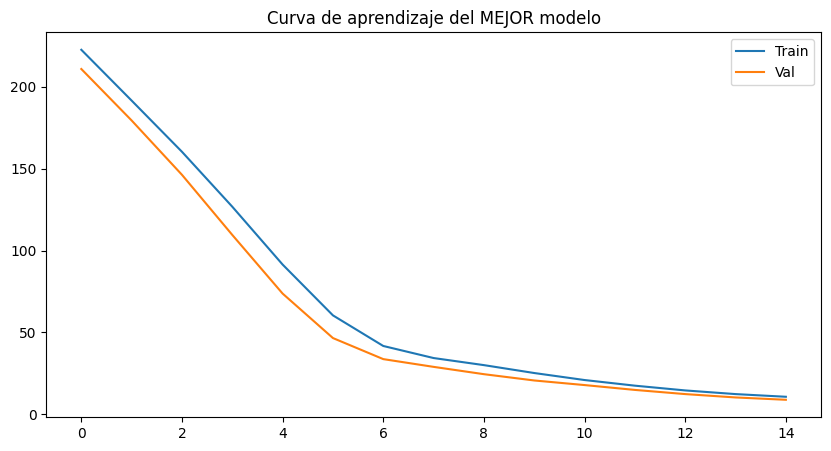

,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Voting Ensemble (Top 3),0.913627,0.467918,0.739922,0.622198
1,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
2,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
3,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
4,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
5,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
6,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
7,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
8,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
9,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165


In [ ]:

def build_model(hp):
    """Construte modelo Keras con hiperparámetros variables para Keras Tuner."""
    model = keras.Sequential()
    model.add(layers.Input(shape=X_train_ann.shape[1:]))
    hp_units = hp.Int('units', min_value=32, max_value=96, step=32)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Dropout opcional
    hp_dropout = hp.Choice('dropout', values=[0.0, 0.2, 0.3])
    if hp.Boolean("dropout"):
        model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(int(hp_units/2), activation='relu'))
    model.add(layers.Dense(1))
    
    # Learning Rate variable
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                    loss='mean_squared_error')
    return model


tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,  # núemro de combinaciones distintas
    executions_per_trial=1,
    directory='my_dir',
    project_name='intro_to_kt',
    overwrite=True
)

print("Iniciando la búsqueda de hiperparámetros con Keras Tuner...")

# Usamos Early Stopping para no perder tiempo en modelos malos
callback_tuning = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train_ann, y_train,
                epochs=50,
                validation_split=0.2,
                callbacks=[callback_tuning],
                verbose=1)

# Obtenemos el mejor modelo y sus hiperparámetros
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

print("\n Mejor modelo construido. Resumen:")
print(f"Neuronas capa 1: {best_hps.get('units')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Usar Dropout: {best_hps.get('dropout')}")

# Entrenamos el mejor modelo
print("Entrenando el modelo GANADOR con configuración robusta ")

history_best = best_model.fit(X_train_ann, y_train,
                                epochs=200,
                                validation_split=0.2,
                                callbacks=[callback],
                                verbose=0)

# Evaluación
mse_test_ft = best_model.evaluate(X_test_ann, y_test, verbose=0)
rmse_test_ft = np.sqrt(mse_test_ft)
y_pred_ft = best_model.predict(X_test_ann).flatten()
r2_test_ft = r2_score(y_test, y_pred_ft)

# Métricas Train
rmse_train_ft = np.sqrt(history_best.history['loss'][-1])
# R2 Train (aproximado)
y_pred_train_ft = best_model.predict(X_train_ann).flatten()
r2_train_ft = r2_score(y_train, y_pred_train_ft)

print(f"RMSE Test (Tuned): {rmse_test_ft:.4f} | R2 Test (Tuned): {r2_test_ft:.4f}")

model_comparative = add_model(model_comparative, "ANN (Fine Tuned KerasTuner)", rmse_train_ft, r2_train_ft, rmse_test_ft, r2_test_ft)


plt.figure(figsize=(10, 5))
plt.plot(history_best.history['loss'], label='Train')
plt.plot(history_best.history['val_loss'], label='Val')
plt.title('Curva de aprendizaje del MEJOR modelo')
plt.legend()
plt.show()

display(model_comparative.sort_values(by='RMSE Test'))

## Conclusiones sobre Redes Neuronales y Fine Tunning

Obtenemos un valor de $R^2 = -138$ y un RMSE de 14.24 siendo nuestro objetivo del mejor modelo un RMSE cercano a 0.74 y un $R^2$ cercano a 0.62 tiene varias implicaciones:

1. El modelo predice ceros o constantes sin sentido para todos los jugadores o una gran parte de ellos.
2. Tuner encuentra como mejor modelo un Learning Rate: 0.001 era bueno para una prueba corta, pero al re-entrenar el modelo final con más épocas (best_model.fit), la inicializacion aleatorio de los pesos fue mala y el modelo no aprendió nada útil.
3. Combinando un learning rate alto para este dataset pequeño, los gradientes explotaron y el modelo no pudo aprender patrones útiles y por ese vemos este valor de RMSE tan alto.

Vamos a realizar un cambio de arquitectura para intentar mejorar el rendimiento de la red neuronal. En vez de usar RELU y usaremos SNN (Self Normalizing Neural Networks) con la función de activación SELU (Scaled Exponential Linear Unit) que ayuda a mantener la media y varianza de las activaciones cerca de 0 y 1 respectivamente, lo que facilita el entrenamiento de redes profundas y mejora la convergencia en datasets pequeños.

Trial 10 Complete [00h 00m 02s]
val_loss: 7.702026844024658

Best val_loss So Far: 1.2060164213180542
Total elapsed time: 00h 00m 43s

MEJOR CONFIGURACIÓN ROBUSTA:
Neuronas: 64
LR: 0.0005
Dropout: 0.0
Entrenando Modelo Final
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
Rendimiento del Modelo Final (SELU Tuned):
RMSE Test: 1.2447
R2 Test:   -0.0692


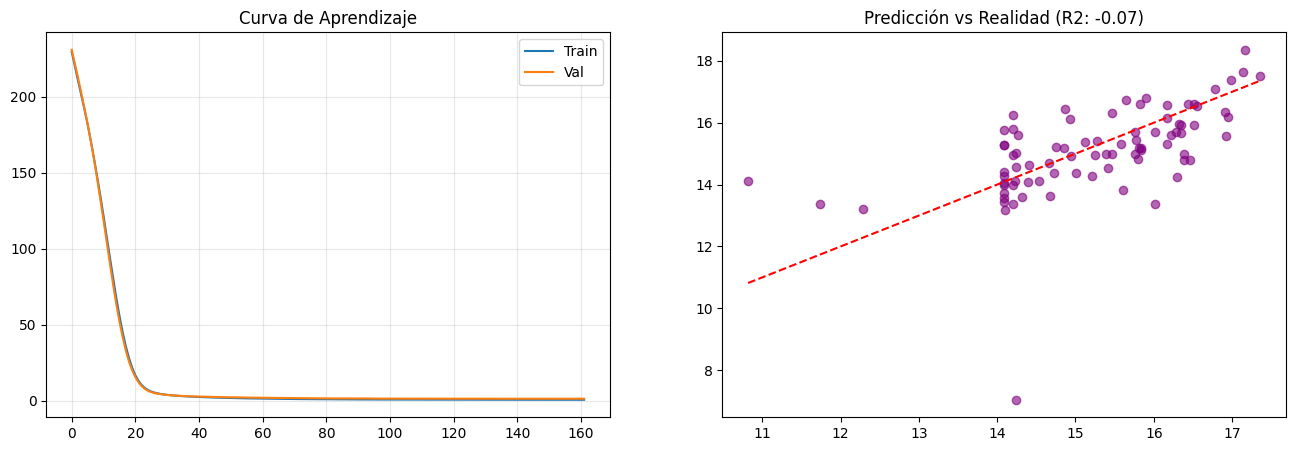

,Model,RMSE Train (CV),R2 Train (CV),RMSE Test,R2 Test
0,Voting Ensemble (Top 3),0.913627,0.467918,0.739922,0.622198
1,Gradient Boosting,0.922601,0.451929,0.761357,0.599992
2,LightGBM (max_depth=5),0.941662,0.433241,0.762542,0.598746
3,XGBoost (learning_rate=0.05),0.948617,0.428657,0.762763,0.598514
4,"Random Forest (n_estimators = 200, max_depth=10)",0.909542,0.475353,0.765476,0.595652
5,"Random Forest (n_estimators = 100, max_depth=10)",0.912227,0.471858,0.769295,0.591607
6,LightGBM (learning_rate=0.05),0.942004,0.436042,0.771676,0.589076
7,Gradient Boosting (Grid Search),0.907133,0.497259,0.771870,0.588869
8,Gradient Boosting (learning_rate=0.05),0.896974,0.488947,0.771870,0.588869
9,Random Forest (n_estimators = 200),0.912486,0.471267,0.772530,0.588165


In [ ]:

def build_model_robust(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=X_train_ann.shape[1:]))
    hp_units = hp.Int('units', min_value=32, max_value=96, step=32)
    model.add(layers.Dense(units=hp_units,
                            activation='selu',
                            kernel_initializer='lecun_normal'))

    hp_dropout = hp.Choice('dropout', values=[0.0, 0.1])
    if hp_dropout > 0:
        model.add(layers.AlphaDropout(hp_dropout)) # AlphaDropout respeta la propiedad SELU

    model.add(layers.Dense(int(hp_units/2),
                            activation='selu',
                            kernel_initializer='lecun_normal'))

    model.add(layers.Dense(1))
    hp_learning_rate = hp.Choice('learning_rate', values=[5e-4, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                    loss='mean_squared_error')
    return model


tuner = kt.RandomSearch(
    build_model_robust,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir_robust',
    project_name='nba_salary_selu',
    overwrite=True
)

print("Iniciando Búsqueda Robusta (SELU Architecture)")

callback_tuning = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

tuner.search(X_train_ann, y_train,
                epochs=100,
                validation_split=0.2,
                callbacks=[callback_tuning],
                verbose=1)

# Entrenamiento del mejor modelo robusto
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

print("\nMEJOR CONFIGURACIÓN ROBUSTA:")
print(f"Neuronas: {best_hps.get('units')}")
print(f"LR: {best_hps.get('learning_rate')}")
print(f"Dropout: {best_hps.get('dropout')}")

print("Entrenando Modelo Final")

callback_final = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_best = best_model.fit(X_train_ann, y_train,
                                epochs=300,
                                validation_split=0.2,
                                callbacks=[callback_final],
                                verbose=0)


# EVALUACIÓN

# Métricas Test
y_pred_ft = best_model.predict(X_test_ann).flatten()
rmse_test_ft = np.sqrt(mean_squared_error(y_test, y_pred_ft))
r2_test_ft = r2_score(y_test, y_pred_ft)

# Métricas Train
rmse_train_ft = np.sqrt(history_best.history['loss'][-1])
r2_train_ft = r2_score(y_train, best_model.predict(X_train_ann).flatten())

print("Rendimiento del Modelo Final (SELU Tuned):")
print(f"RMSE Test: {rmse_test_ft:.4f}")
print(f"R2 Test:   {r2_test_ft:.4f}")


model_comparative = add_model(model_comparative, "ANN (SELU Tuned)", rmse_train_ft, r2_train_ft, rmse_test_ft, r2_test_ft)


fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Curva
ax[0].plot(history_best.history['loss'], label='Train')
ax[0].plot(history_best.history['val_loss'], label='Val')
ax[0].set_title('Curva de Aprendizaje')
ax[0].legend()
ax[0].grid(True, alpha=0.3)


ax[1].scatter(y_test, y_pred_ft, alpha=0.6, color='purple')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[1].set_title(f'Predicción vs Realidad (R2: {r2_test_ft:.2f})')

plt.show()

display(model_comparative.sort_values(by='RMSE Test'))

Al cambiar la arquitectura de la red neuronal obtenemos como mejor modelo:
- Neuronas: 64
- LR: 0.0005
- Dropout: 0.0
- RMSE Test: 1.2447
- R2 Test:   -0.0692

En la gráfica de la izquierda (Curva de aprendizaje del modelo con SELU):
 - Es una gráfica engañosa debido a que el error baja prácticamente a 0 en ambas curvas, lo que nos lleva a pendar que el modelo ha aprendido bien los datos, pero al mirar la gráfica de la derecha (Predicciones vs Valores Reales) vemos que el modelo memoriza los datos (overfitting) y no generaliza bien a datos nuevos.

En la gráfica de la derecha (Predicciones vs Valores Reales):
 - El resultado negativo indica que la red neuronal predice peor que un modelo que simplemente predice la media de los salarios, y observamos que el modelo realiza predicciones sin formar una diagonal clara, lo que indica que no está capturando la relación entre las características y el salario de manera efectiva.

## 4. Conclusiones

El objetivo de este proyecto era desarrollar un modelo predictivo del salario de jugadores de la NBA basándose en sus estadísticas y características. A lo largo del análisis exploratorio de datos (EDA) y el desarrollo de modelos predictivos, hemos obtenido varias conclusiones clave:

1. Análisis Exploratorio de Datos (EDA):
   - La limpieza de datos duplicados y nulos fue esencial para garantizar la calidad del dataset.
   - El análisis de correlación confirma que características como Puntos, Asistencias y Edad tienen una fuerte relación con el salario.
   - La distribución salarias presentó una fuerte asimetría (muy pocos jugadores con salarios extremadamente altos), lo que motivó la transformación logarítmica de la variable objetivo para mejorar la estabilidad del modelo.
2. Desarrollo de Modelos Predictivos:
   - Los modelos de machine learning tradicionales (Gradient Boosting, LightGBM, XGBoost) demostraron ser más efectivos que las redes neuronales (ANN) para este problema específico.
   - El modelo de ensamble Voting Regressor, que combina las predicciones de varios modelos fuertes, logró el mejor rendimiento.
   - **Precisión RMSE (Test)** del modelo de ensamble fue de 0.7399, es el error promedio en la escala logarítmica, lo que indica una buena capacidad de predicción, aunque aún hay margen de mejora es un buen modelo para predecir salarios en la NBA, ya que en ciertas ocasiones los salarios pueden estar influenciados por factores intangibles no capturados en los datos.
   - **Explicabiliad R² (Test)** del modelo de ensamble fue de 0.6221, lo que indica que el modelo explica aproximadamente el 62.21% de la variabilidad en los salarios de los jugadores, lo que es un buen resultado considerando la complejidad del problema y la capacidad de los jugadores y sus agentes para negociar contratos. El 38% de los datos no explicados puede deberse a factores externos no capturados en las estadísticas (marketing, liderazgo, potencial futuro, etc).
   - El análisis de características más importantes según el modelo de ensamble reveló que la Edad, Puntos y Partidos Jugados son factores clave que influyen en el salario.
   - El análisis de residuos indicó que el modelo tiene un buen ajuste y no presenta patrones sistemáticos en los errores de predicción.
3. Redes Neuronales (ANN):
   - A pesar de los esfuerzos en el fine tunning y la implementación de técnicas como Early Stopping, las redes neuronales no lograron superar el rendimiento de los modelos tradicionales.
   - Los resultados negativos en métricas como RMSE y R² sugieren que las redes neuronales no fueron capaces de capturar eficazmente la relación entre las características y el salario en este caso.
   - Las redes neuronales necesitan de una gran cantidad de datos para generalizar bien, y en este caso el dataset era relativamente pequeño.
3. Machine Learning vs Deep Learning:
   - A pesar de aplicar técnicas avanzadas de optimización y ajuste de hiperparámetros, las redes neuronales no lograron superar el rendimiento de los modelos tradicionales de machine learning en este caso específico.
   - Este proyecto afirma que no siempre las técnicas más complejas (Deep Learning) son las mejores para todos los problemas, y que la elección del modelo debe basarse en la naturaleza del problema y la cantidad de datos disponibles. Para datos estructurados y tabulares de menos de 1000 muestras los algoritmos basados en árboles de decision Boosting optenen mejores resultados que el Deep Learning. Las redes neuronales son más adecuadas para grandes volúmenes de datos para evita el sobreajuste y capturar patrones complejos.